# Analyzing Booking Trends in the Hospitality Industry

### Project Overview

Hotel Haven is a luxury hotel chain that wants to better understand customer booking patterns and predict whether a booking is likely to be canceled or not canceled.

High cancellation rates can lead to lost revenue, poor resource planning, and operational inefficiencies. This project uses historical booking data to explore key factors linked to cancellations and build a machine learning model that can predict booking status.

### Project Objective

The main objective of this project is to analyze hotel booking data and develop a predictive model that determines whether a customer booking will be canceled or not canceled.

The analysis will cover data cleaning, exploratory data analysis, feature engineering, model development, model evaluation, and business recommendations.

In [1]:
# Import libraries for data analysis and visualization

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset

df = pd.read_csv('booking.csv')

In [3]:
# Display the first five rows of the dataset

df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [4]:
# Display the last five rows of the dataset

df.tail()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
36280,INN36282,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,Online,0,0,0,115.00,1,9/13/2018,Canceled
36281,INN36283,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,Online,0,0,0,107.55,1,10/15/2017,Not_Canceled
36282,INN36284,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,Online,0,0,0,105.61,1,12/26/2018,Not_Canceled
36283,INN36285,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,Offline,0,0,0,96.90,1,7/6/2018,Not_Canceled
36284,INN36286,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,Online,0,0,0,133.44,3,10/18/2018,Not_Canceled


### Data Overview

This section provides an initial overview of the dataset, including the number of rows and columns, column names, data types, and general structure.

Understanding the dataset structure is important before cleaning, analysis, and model development.

In [5]:
# Check the number of rows and columns in the dataset

df.shape

(36285, 17)

In [6]:
# Display all column names in the dataset

df.columns

Index(['Booking_ID', 'number of adults', 'number of children',
       'number of weekend nights', 'number of week nights', 'type of meal',
       'car parking space', 'room type', 'lead time', 'market segment type',
       'repeated', 'P-C', 'P-not-C', 'average price', 'special requests',
       'date of reservation', 'booking status'],
      dtype='object')

In [7]:
# Check data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [8]:
# Generate summary statistics for numerical columns

df.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [9]:
# Generate summary statistics for categorical columns

df.describe(include='object')

,Booking_ID,type of meal,room type,market segment type,date of reservation,booking status
count,36285,36285,36285,36285,36285,36285
unique,36285,4,7,5,553,2
top,INN36286,Meal Plan 1,Room_Type 1,Online,10/13/2018,Not_Canceled
freq,1,27842,28138,23221,254,24396


#### Initial Data Overview Observations

The dataset contains 36,285 rows and 17 columns. There are no missing values based on the non-null count shown in the dataset information.

The dataset includes a mix of numerical, categorical, binary, and date-related variables. The target variable is *booking status*, which has two categories: *Not_Canceled* and *Canceled*. This confirms that the project is a supervised classification problem.

The *Booking_ID* column is unique for each record and will likely not be useful for modeling. The *date of reservation* column is currently stored as an object, so it will need to be converted to a datetime format during data cleaning or feature engineering.

### Data Quality Checks

This section checks for common data quality issues such as missing values and duplicate records. These checks help determine whether the dataset needs cleaning before deeper analysis and modeling.

In [10]:
# Check for missing values in each column

df.isnull().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

In [11]:
# Check the percentage of missing values in each column

missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

Booking_ID                  0.0
number of adults            0.0
number of children          0.0
number of weekend nights    0.0
number of week nights       0.0
type of meal                0.0
car parking space           0.0
room type                   0.0
lead time                   0.0
market segment type         0.0
repeated                    0.0
P-C                         0.0
P-not-C                     0.0
average price               0.0
special requests            0.0
date of reservation         0.0
booking status              0.0
dtype: float64

In [12]:
# Check for duplicate rows

df.duplicated().sum()

np.int64(0)

In [13]:
# Check for duplicate Booking_ID values

df['Booking_ID'].duplicated().sum()

np.int64(0)

#### Data Quality Check Observations

The dataset does not contain missing values or duplicate records. Each *Booking_ID* is also unique, which confirms that each row represents a separate booking record.

Since no missing or duplicate records were found, no rows need to be removed at this stage. The next cleaning step is to check whether the date column is valid and properly formatted.

### Date Column Check

The *date of reservation* column needs to be converted into a datetime format so it can be used for time-based analysis.

This step checks whether the date values are valid and identifies any records that may need correction or special handling.

In [14]:
# Check the current data type of the date column

df['date of reservation'].dtype

dtype('O')

In [15]:
# Convert date of reservation to datetime format and identify invalid dates

df['date of reservation_cleaned'] = pd.to_datetime(df['date of reservation'], errors='coerce')

invalid_dates = df[df['date of reservation_cleaned'].isnull()]

invalid_dates[['Booking_ID', 'date of reservation']]

,Booking_ID,date of reservation
2626,INN02627,2018-2-29
3677,INN03678,2018-2-29
5600,INN05601,2018-2-29
6343,INN06344,2018-2-29
7648,INN07649,2018-2-29
8000,INN08001,2018-2-29
8989,INN08990,2018-2-29
9153,INN09154,2018-2-29
9245,INN09246,2018-2-29
9664,INN09665,2018-2-29


In [16]:
# Count the number of invalid dates

invalid_dates.shape[0]

37

#### Date Column Observation

The *date of reservation* column was originally stored as an object instead of a datetime format. After converting it to datetime, 37 invalid dates were identified.

All invalid dates were recorded as *2018-2-29*. Since 2018 was not a leap year, February 29 did not exist in that year. These records represent a very small portion of the dataset, so they will be removed to avoid making assumptions about the correct reservation date.

In [17]:
# Remove rows with invalid dates

df = df.dropna(subset=['date of reservation_cleaned'])

In [18]:
# Check the shape after removing invalid dates

df.shape

(36248, 18)

In [19]:
# Replace the original date column with the cleaned datetime column

df['date of reservation'] = df['date of reservation_cleaned']

In [20]:
# Drop the temporary cleaned date column

df = df.drop(columns=['date of reservation_cleaned'])

In [21]:
# Confirm that the date column is now in datetime format

df['date of reservation'].dtype

dtype('<M8[ns]')

In [22]:
# Confirm final shape after dropping the temporary cleaned date column

df.shape

(36248, 17)

#### Date Cleaning Result

The invalid reservation dates were removed, reducing the dataset from 36,285 rows to 36,248 rows. The *date of reservation* column has now been converted from object format to datetime format.

This means the date column is now ready for time-based analysis, such as extracting the reservation year, month, quarter, or day of the week.

### Categorical Variable Check

This section reviews the unique values in the categorical columns. This helps identify spelling inconsistencies, unusual categories, and variables that may need encoding before machine learning.

In [23]:
# Identify categorical columns

categorical_columns = df.select_dtypes(include='object').columns

categorical_columns

Index(['Booking_ID', 'type of meal', 'room type', 'market segment type',
       'booking status'],
      dtype='object')

In [24]:
# Display unique values for each categorical column

for col in categorical_columns:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 50)

Booking_ID:
['INN00001' 'INN00002' 'INN00003' ... 'INN36284' 'INN36285' 'INN36286']
--------------------------------------------------
type of meal:
['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3']
--------------------------------------------------
room type:
['Room_Type 1' 'Room_Type 4' 'Room_Type 2' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3']
--------------------------------------------------
market segment type:
['Offline' 'Online' 'Corporate' 'Aviation' 'Complementary']
--------------------------------------------------
booking status:
['Not_Canceled' 'Canceled']
--------------------------------------------------


In [25]:
# Count unique values in each categorical column

df[categorical_columns].nunique()

Booking_ID             36248
type of meal               4
room type                  7
market segment type        5
booking status             2
dtype: int64

#### Categorical Variable Observations

The categorical variables appear to have consistent category labels, with no obvious spelling or formatting issues.

*Booking_ID* is stored as an object column, but it is only a unique identifier and will not be useful for analysis or model training. The main categorical predictor variables are *type of meal*, *room type*, and *market segment type*. The target variable is *booking status*, which contains two classes: *Not_Canceled* and *Canceled*.

### Target Variable Distribution

The target variable for this project is *booking status*. This section checks how many bookings were canceled and how many were not canceled.

Understanding the target distribution is important because class imbalance can affect model performance and the choice of evaluation metrics.

In [26]:
# Count the number of bookings in each booking status category

df['booking status'].value_counts()

booking status
Not_Canceled    24366
Canceled        11882
Name: count, dtype: int64

In [27]:
# Calculate the percentage distribution of booking status

df['booking status'].value_counts(normalize=True) * 100

booking status
Not_Canceled    67.22026
Canceled        32.77974
Name: proportion, dtype: float64

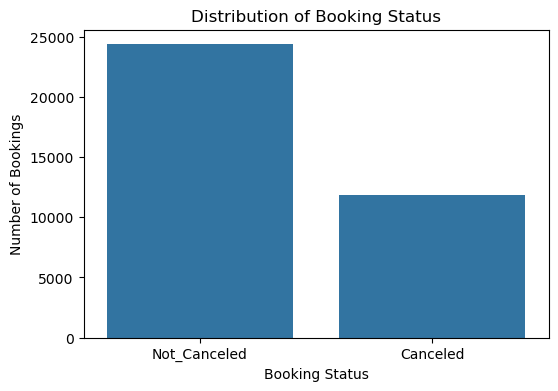

In [28]:
# Visualize the distribution of booking status

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='booking status')
plt.title('Distribution of Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')
plt.show()

#### Target Variable Observation

Most bookings in the dataset were not canceled. After removing invalid date records, 24,366 bookings were *Not_Canceled*, representing about 67.2% of the dataset, while 11,882 bookings were *Canceled*, representing about 32.8%.

This shows that the target variable is somewhat imbalanced. Because of this, model evaluation should not rely on accuracy alone. Metrics such as precision, recall, F1-score, and confusion matrix will be important when evaluating the cancellation prediction model.

### Numerical Variable Check

This section reviews the numerical variables in the dataset. The goal is to understand their distributions, ranges, and possible outliers before moving into deeper exploratory analysis.

In [29]:
# Identify numerical columns

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

numerical_columns

Index(['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'car parking space', 'lead time', 'repeated',
       'P-C', 'P-not-C', 'average price', 'special requests'],
      dtype='object')

In [30]:
# Display summary statistics for numerical columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
number of adults,36248.0,1.845178,0.518671,0.0,2.0,2.00,2.0,4.0
number of children,36248.0,0.105302,0.402597,0.0,0.0,0.00,0.0,10.0
number of weekend nights,36248.0,0.810445,0.870938,0.0,0.0,1.00,2.0,7.0
number of week nights,36248.0,2.204508,1.410825,0.0,1.0,2.00,3.0,17.0
car parking space,36248.0,0.030926,0.173119,0.0,0.0,0.00,0.0,1.0
lead time,36248.0,85.282360,85.961536,0.0,17.0,57.00,126.0,443.0
repeated,36248.0,0.025546,0.157779,0.0,0.0,0.00,0.0,1.0
P-C,36248.0,0.023339,0.368432,0.0,0.0,0.00,0.0,13.0
P-not-C,36248.0,0.152919,1.753126,0.0,0.0,0.00,0.0,58.0
average price,36248.0,103.435350,35.081308,0.0,80.3,99.45,120.0,540.0


In [31]:
# Check value counts for binary indicator columns

binary_columns = ['car parking space', 'repeated']

for col in binary_columns:
    print(f"{col}:")
    print(df[col].value_counts())
    print("-" * 50)

car parking space:
car parking space
0    35127
1     1121
Name: count, dtype: int64
--------------------------------------------------
repeated:
repeated
0    35322
1      926
Name: count, dtype: int64
--------------------------------------------------


#### Numerical Variable Observations

The numerical columns show a mix of count variables, binary indicators, and continuous values.

Most bookings include 1 to 2 adults, and most bookings have no children. The average booking includes about 2 week nights and less than 1 weekend night.

The *lead time* variable has a wide range, from 0 to 443 days, which suggests there may be outliers or highly advanced bookings. The *average price* variable also has a wide range, from 0 to 540, so it should be explored further during outlier analysis.

The *car parking space* and *repeated* columns are binary indicators. Most bookings did not include parking, and most customers were not repeat customers.

The *P-C* and *P-not-C* columns appear to be numerical, but their maximum values are greater than 1. Since the project description labels them as binary indicators, these columns need to be inspected more closely before deciding how to use them in analysis and modeling.

In [32]:
# Check unique values in P-C and P-not-C

profile_columns = ['P-C', 'P-not-C']

for col in profile_columns:
    print(f"{col}:")
    print(sorted(df[col].unique()))
    print("-" * 50)

P-C:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(11), np.int64(13)]
--------------------------------------------------
P-not-C:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58)

In [33]:
# Check value counts for P-C and P-not-C

for col in profile_columns:
    print(f"{col}:")
    print(df[col].value_counts().sort_index())
    print("-" * 50)

P-C:
P-C
0     35911
1       197
2        46
3        43
4        10
5        11
6         1
11       25
13        4
Name: count, dtype: int64
--------------------------------------------------
P-not-C:
P-not-C
0     35439
1       227
2       112
3        80
4        65
5        60
6        36
7        24
8        23
9        19
10       18
11       14
12       12
13        7
14        9
15        8
16        7
17        6
18        6
19        6
20        6
21        6
22        6
23        3
24        3
25        3
26        2
27        3
28        2
29        2
30        2
31        2
32        2
33        1
34        1
35        1
36        1
37        1
38        1
39        1
40        1
41        1
42        1
43        1
44        2
45        1
46        1
47        1
48        2
49        1
50        1
51        1
52        1
53        1
54        1
55        1
56        1
57        1
58        1
Name: count, dtype: int64
--------------------------------------------------


In [34]:
# Check zero values in selected numerical columns

zero_check_columns = [
    'number of adults',
    'number of children',
    'number of weekend nights',
    'number of week nights',
    'lead time',
    'average price',
    'special requests'
]

for col in zero_check_columns:
    print(f"{col}:")
    print((df[col] == 0).sum())
    print("-" * 50)

number of adults:
139
--------------------------------------------------
number of children:
33550
--------------------------------------------------
number of weekend nights:
16876
--------------------------------------------------
number of week nights:
2383
--------------------------------------------------
lead time:
1295
--------------------------------------------------
average price:
545
--------------------------------------------------
special requests:
19754
--------------------------------------------------


#### Profile and Zero-Value Observations

The *P-C* and *P-not-C* columns were described as binary indicators in the project documentation, but the dataset shows values greater than 1. Because of this, they will be treated as numerical count-like variables instead of binary variables at this stage.

Several numerical columns contain zero values. Many of these are reasonable, such as bookings with no children, no weekend nights, no parking, no previous repeat status, or no special requests. However, *average price* has 545 zero values, which should be explored further because a booking price of zero may represent complimentary bookings, missing price information, or special booking cases.

### Date-Based Feature Engineering

The *date of reservation* column can provide useful time-based information. New features will be created from the reservation date to support seasonal and time-based analysis.

In [35]:
# Create date-based features from the reservation date

df['reservation_year'] = df['date of reservation'].dt.year
df['reservation_month'] = df['date of reservation'].dt.month
df['reservation_day'] = df['date of reservation'].dt.day
df['reservation_day_of_week'] = df['date of reservation'].dt.day_name()
df['reservation_quarter'] = df['date of reservation'].dt.quarter

In [36]:
# Preview the new date-based features

df[['date of reservation', 'reservation_year', 'reservation_month',
    'reservation_day', 'reservation_day_of_week', 'reservation_quarter']].head()

,date of reservation,reservation_year,reservation_month,reservation_day,reservation_day_of_week,reservation_quarter
0,2015-10-02,2015,10,2,Friday,4
1,2018-11-06,2018,11,6,Tuesday,4
2,2018-02-28,2018,2,28,Wednesday,1
3,2017-05-20,2017,5,20,Saturday,2
4,2018-04-11,2018,4,11,Wednesday,2


In [37]:
# Check the updated dataset shape

df.shape

(36248, 22)

#### Date-Based Feature Engineering Observation

Five new date-based features were created from the *date of reservation* column: *reservation_year*, *reservation_month*, *reservation_day*, *reservation_day_of_week*, and *reservation_quarter*.

These new features will support time-based analysis, such as checking whether cancellations vary by year, month, day of the week, or quarter.

### Additional Feature Engineering

This section creates additional features that may help explain booking patterns and cancellation behaviour.

The new features include total length of stay, total number of guests, and whether the booking includes children.

In [38]:
# Create additional booking-related features

df['total_nights'] = df['number of weekend nights'] + df['number of week nights']
df['total_guests'] = df['number of adults'] + df['number of children']
df['has_children'] = np.where(df['number of children'] > 0, 1, 0)

In [39]:
# Preview the new booking-related features

df[['number of adults', 'number of children', 'total_guests',
    'number of weekend nights', 'number of week nights', 'total_nights',
    'has_children']].head()

,number of adults,number of children,total_guests,number of weekend nights,number of week nights,total_nights,has_children
0,1,1,2,2,5,7,1
1,1,0,1,1,3,4,0
2,2,1,3,1,3,4,1
3,1,0,1,0,2,2,0
4,1,0,1,1,2,3,0


In [40]:
# Check the updated dataset shape

df.shape

(36248, 25)

#### Additional Feature Engineering Observation

Three new booking-related features were created: *total_nights*, *total_guests*, and *has_children*.

These features make the dataset easier to analyze because they summarize related information into clearer variables. For example, *total_nights* gives the full length of stay, *total_guests* gives the total number of people in the booking, and *has_children* identifies whether a booking includes children.

In [41]:
# Check summary statistics for the new features

df[['total_nights', 'total_guests', 'has_children']].describe()

,total_nights,total_guests,has_children
count,36248.000000,36248.00000,36248.000000
mean,3.014953,1.95048,0.074432
std,1.786041,0.65008,0.262476
min,0.000000,1.00000,0.000000
25%,2.000000,2.00000,0.000000
50%,3.000000,2.00000,0.000000
75%,4.000000,2.00000,0.000000
max,24.000000,12.00000,1.000000


In [42]:
# Check bookings with zero total guests

df[df['total_guests'] == 0]

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,...,date of reservation,booking status,reservation_year,reservation_month,reservation_day,reservation_day_of_week,reservation_quarter,total_nights,total_guests,has_children


In [43]:
# Count bookings with zero total guests

(df['total_guests'] == 0).sum()

np.int64(0)

In [44]:
# Check bookings with zero total nights

df[df['total_nights'] == 0]

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,...,date of reservation,booking status,reservation_year,reservation_month,reservation_day,reservation_day_of_week,reservation_quarter,total_nights,total_guests,has_children
209,INN00210,1,0,0,0,Meal Plan 1,0,Room_Type 1,4,Complementary,...,2018-02-27,Not_Canceled,2018,2,27,Tuesday,1,0,1,0
1158,INN01159,2,0,0,0,Meal Plan 1,0,Room_Type 1,145,Online,...,2018-07-05,Not_Canceled,2018,7,5,Thursday,3,0,2,0
1403,INN01404,3,0,0,0,Meal Plan 1,0,Room_Type 4,57,Online,...,2018-04-01,Not_Canceled,2018,4,1,Sunday,2,0,3,0
1907,INN01908,2,0,0,0,Meal Plan 2,0,Room_Type 1,247,Online,...,2018-06-06,Not_Canceled,2018,6,6,Wednesday,2,0,2,0
1986,INN01987,2,0,0,0,Meal Plan 1,0,Room_Type 1,43,Online,...,2017-10-17,Not_Canceled,2017,10,17,Tuesday,4,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33218,INN33219,1,0,0,0,Meal Plan 1,0,Room_Type 1,1,Online,...,2018-02-06,Not_Canceled,2018,2,6,Tuesday,1,0,1,0
33537,INN33538,2,0,0,0,Meal Plan 1,0,Room_Type 2,166,Online,...,2018-04-21,Not_Canceled,2018,4,21,Saturday,2,0,2,0
34750,INN34751,1,0,0,0,Meal Plan 1,0,Room_Type 4,1,Complementary,...,2017-10-22,Not_Canceled,2017,10,22,Sunday,4,0,1,0
35472,INN35473,1,0,0,0,Meal Plan 1,0,Room_Type 1,7,Online,...,2018-02-15,Not_Canceled,2018,2,15,Thursday,1,0,1,0


In [45]:
# Count bookings with zero total nights

(df['total_nights'] == 0).sum()

np.int64(78)

#### New Feature Quality Check Observation

The new features were checked for unusual values. There were no bookings with zero total guests, which means every booking has at least one guest recorded.

There were 78 bookings with zero total nights. These records may represent same-day bookings, day-use bookings, or possible data entry issues. Since they make up a very small portion of the dataset, they will be kept for now and reviewed again before model training.

## Exploratory Data Analysis

### Univariate Analysis

Univariate analysis looks at one variable at a time. This helps understand the distribution of individual variables before comparing them with other variables or the target variable.

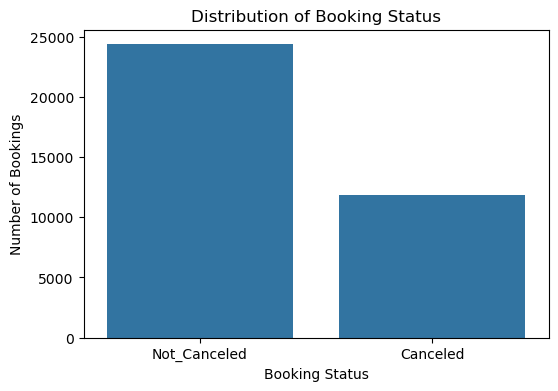

In [46]:
# Visualize booking status distribution

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='booking status')
plt.title('Distribution of Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')
plt.show()

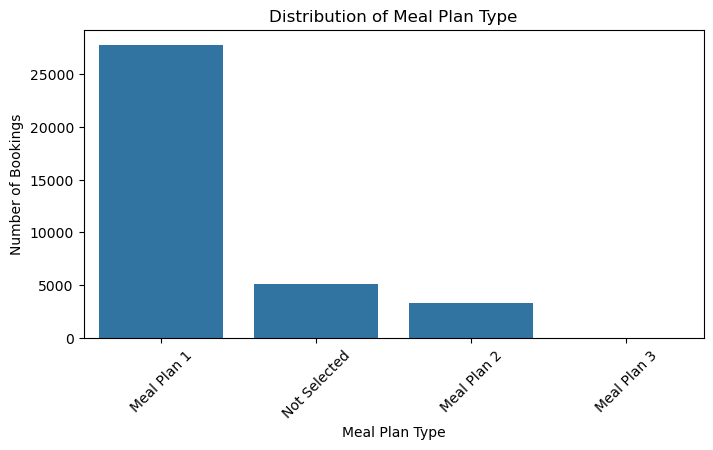

In [47]:
# Visualize meal plan distribution

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='type of meal', order=df['type of meal'].value_counts().index)
plt.title('Distribution of Meal Plan Type')
plt.xlabel('Meal Plan Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.show()

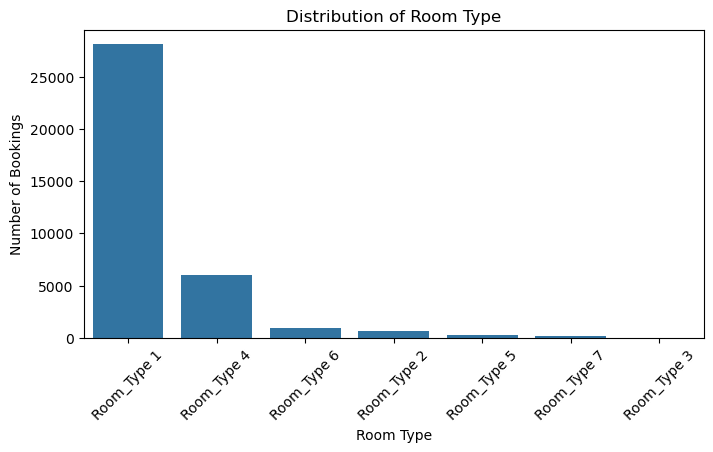

In [48]:
# Visualize room type distribution

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='room type', order=df['room type'].value_counts().index)
plt.title('Distribution of Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.show()

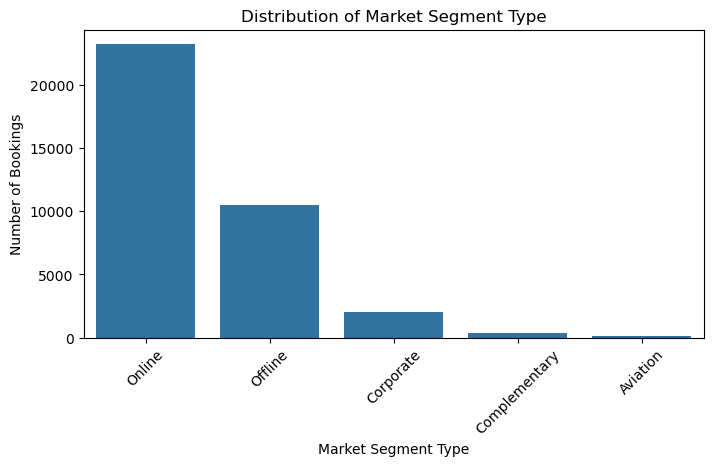

In [49]:
# Visualize market segment distribution

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='market segment type', order=df['market segment type'].value_counts().index)
plt.title('Distribution of Market Segment Type')
plt.xlabel('Market Segment Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.show()

#### Categorical Univariate Analysis Observations

Most bookings were not canceled, although canceled bookings still make up a meaningful portion of the dataset.

For meal plans, *Meal Plan 1* is by far the most common option. *Not Selected* and *Meal Plan 2* appear less often, while *Meal Plan 3* is rarely used.

For room type, *Room_Type 1* is the most common room category by a wide margin, followed by *Room_Type 4*. The remaining room types have much lower booking volumes.

For market segment, most bookings came through the *Online* segment, followed by *Offline*. *Corporate*, *Complementary*, and *Aviation* bookings are much less common.

### Numerical Univariate Analysis

This section reviews the distribution of selected numerical variables. These variables may help explain booking behaviour and cancellation patterns.

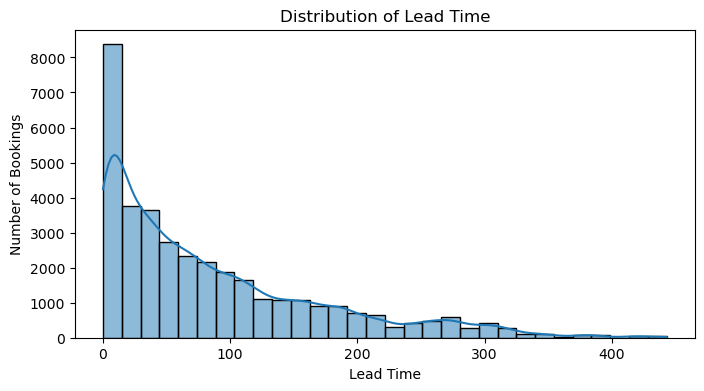

In [50]:
# Visualize the distribution of lead time

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='lead time', bins=30, kde=True)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Number of Bookings')
plt.show()

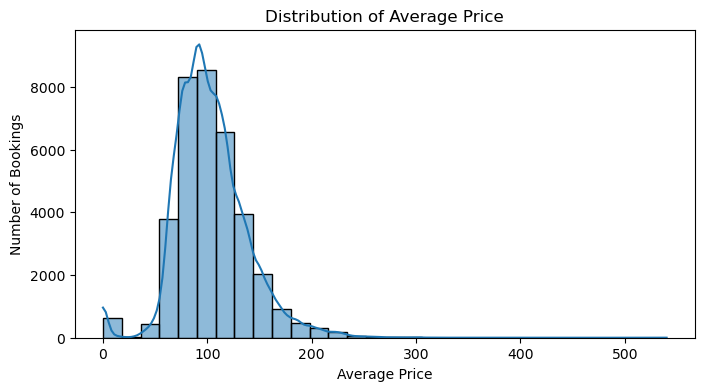

In [51]:
# Visualize the distribution of average price

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='average price', bins=30, kde=True)
plt.title('Distribution of Average Price')
plt.xlabel('Average Price')
plt.ylabel('Number of Bookings')
plt.show()

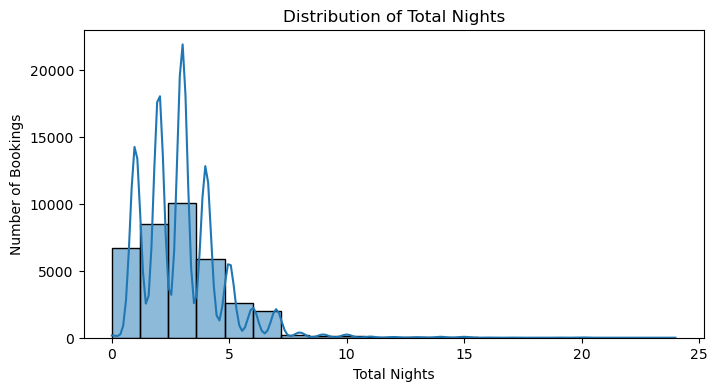

In [52]:
# Visualize the distribution of total nights

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='total_nights', bins=20, kde=True)
plt.title('Distribution of Total Nights')
plt.xlabel('Total Nights')
plt.ylabel('Number of Bookings')
plt.show()

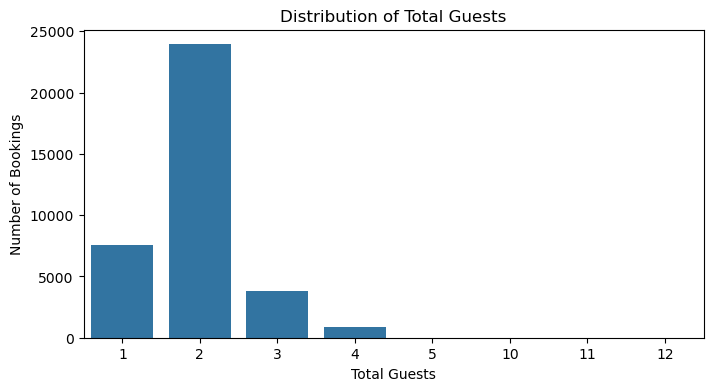

In [53]:
# Visualize the distribution of total guests

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='total_guests')
plt.title('Distribution of Total Guests')
plt.xlabel('Total Guests')
plt.ylabel('Number of Bookings')
plt.show()

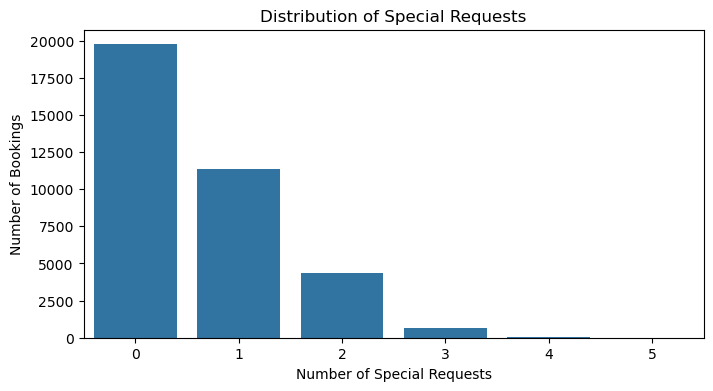

In [54]:
# Visualize the distribution of special requests

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='special requests')
plt.title('Distribution of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Number of Bookings')
plt.show()

#### Numerical Univariate Analysis Observations

The *lead time* distribution is right-skewed. Most bookings were made with a shorter lead time, but some bookings were made far in advance, with lead times extending beyond 400 days.

The *average price* distribution is mostly concentrated around the mid-range, especially around 80 to 120. There are some very low prices, including zero values, and a few very high prices, which may need to be reviewed during outlier analysis.

Most bookings were for short stays, with *total_nights* commonly falling between 1 and 5 nights. Longer stays are less common.

Most bookings had 2 total guests, followed by bookings with 1 guest and 3 guests. Larger group bookings are rare.

Most customers made no special requests, followed by customers with 1 or 2 special requests. Bookings with 3 or more special requests are much less common.

### Outlier Check

Boxplots are used to check for possible outliers in selected numerical variables.

At this stage, the goal is to identify possible outliers, not immediately remove them. Some outliers may be valid business cases, such as very long lead times or high-priced bookings.

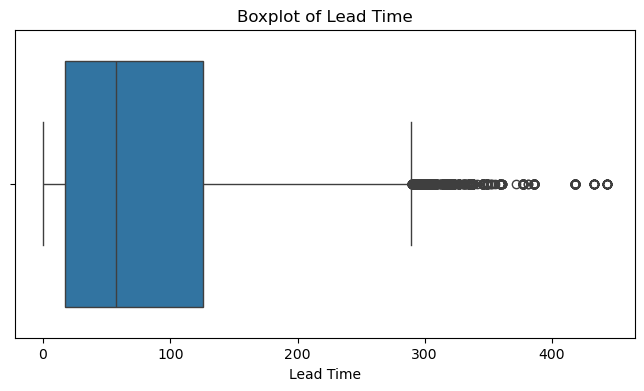

In [55]:
# Check outliers in lead time

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='lead time')
plt.title('Boxplot of Lead Time')
plt.xlabel('Lead Time')
plt.show()

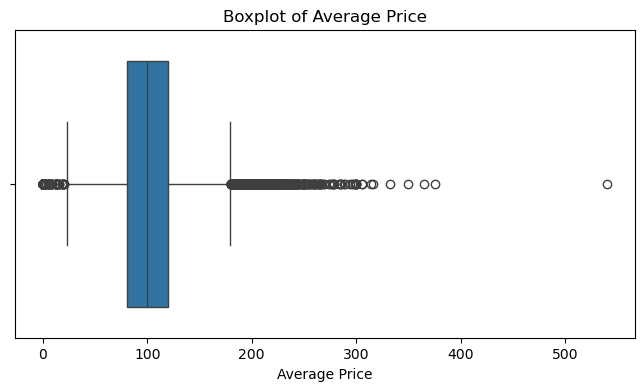

In [56]:
# Check outliers in average price

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='average price')
plt.title('Boxplot of Average Price')
plt.xlabel('Average Price')
plt.show()

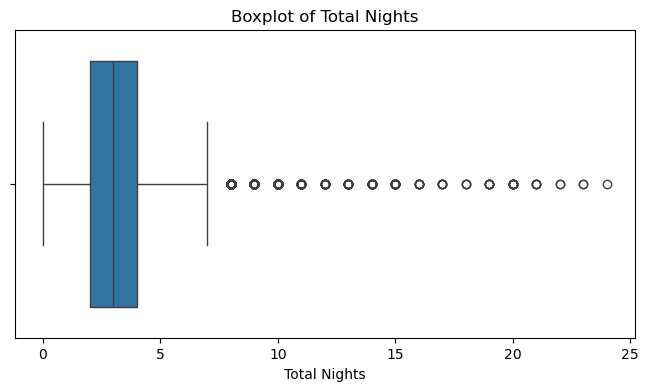

In [57]:
# Check outliers in total nights

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='total_nights')
plt.title('Boxplot of Total Nights')
plt.xlabel('Total Nights')
plt.show()

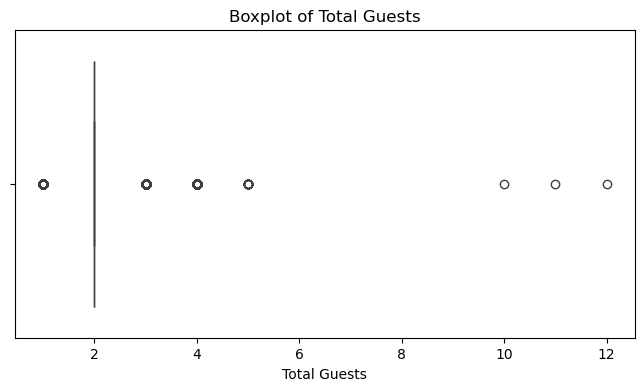

In [58]:
# Check outliers in total guests

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='total_guests')
plt.title('Boxplot of Total Guests')
plt.xlabel('Total Guests')
plt.show()

#### Outlier Check Observations

The boxplots show possible outliers in several numerical variables.

*Lead time* has high values above the typical range, with some bookings made more than 400 days in advance. These may be valid advanced bookings, so they should not be removed automatically.

*Average price* also shows both very low and very high values. The zero-price bookings and very high-price bookings should be explored further before deciding whether they are valid or unusual.

*Total_nights* has some longer stays that appear as outliers, but these may represent valid extended stays.

*Total_guests* also has a few high values, including group bookings with 10 or more guests. Since these may be valid bookings, they will be kept for now.

At this stage, the outliers will be noted rather than removed. A final decision can be made before model training if any values appear unrealistic or harmful to model performance.

### Outlier Count Using IQR Method

The IQR method is used to estimate the number of potential outliers in selected numerical variables. This helps quantify the outliers that were seen visually in the boxplots.

In [59]:
# Define a function to count outliers using the IQR method

def count_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return {
        'column': column,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': outliers.shape[0],
        'outlier_percentage': round((outliers.shape[0] / len(data)) * 100, 2)
    }

In [60]:
# Count outliers for selected numerical variables

outlier_columns = ['lead time', 'average price', 'total_nights', 'total_guests']

outlier_summary = pd.DataFrame([count_outliers_iqr(df, col) for col in outlier_columns])

outlier_summary

,column,lower_bound,upper_bound,outlier_count,outlier_percentage
0,lead time,-146.50,289.50,1332,3.67
1,average price,20.75,179.55,1692,4.67
2,total_nights,-1.00,7.00,582,1.61
3,total_guests,2.00,2.00,12315,33.97


#### IQR Outlier Summary Observation

The IQR method identified potential outliers in *lead time*, *average price*, *total_nights*, and *total_guests*.

For *lead time*, *average price*, and *total_nights*, the outlier percentages are relatively small. These values may represent valid booking patterns, such as bookings made far in advance, high-priced rooms, or longer stays.

For *total_guests*, the IQR method flagged a large percentage of records as outliers because most bookings have exactly 2 guests. This does not mean the other guest counts are invalid. It only shows that *total_guests* is highly concentrated around 2.

At this stage, the outliers will be kept. They will be reviewed again before model training if needed.

## Bivariate Analysis

Bivariate analysis compares two variables at a time. In this section, the focus is on understanding how different booking features relate to *booking status*.

In [61]:
# Calculate cancellation rate by meal plan

meal_cancellation = df.groupby('type of meal')['booking status'].value_counts(normalize=True).unstack() * 100

meal_cancellation

booking status,Canceled,Not_Canceled
type of meal,,
Meal Plan 1,31.194937,68.805063
Meal Plan 2,45.625189,54.374811
Meal Plan 3,20.000000,80.000000
Not Selected,33.112454,66.887546


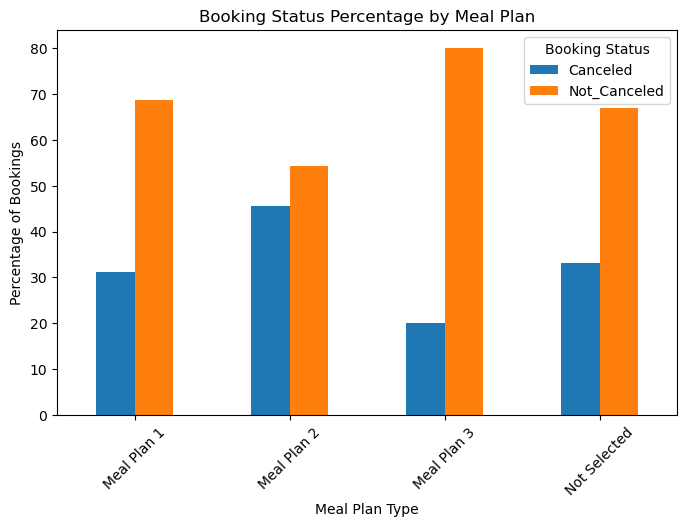

In [62]:
# Visualize cancellation rate by meal plan

meal_cancellation.plot(kind='bar', figsize=(8, 5))

plt.title('Booking Status Percentage by Meal Plan')
plt.xlabel('Meal Plan Type')
plt.ylabel('Percentage of Bookings')
plt.xticks(rotation=45)
plt.legend(title='Booking Status')
plt.show()

#### Booking Status by Meal Plan Observation

Cancellation rates vary across meal plan types. *Meal Plan 2* has the highest cancellation rate at about 45.6%, while *Meal Plan 3* has the lowest cancellation rate at 20.0%.

*Meal Plan 1* and *Not Selected* have similar cancellation rates, both around 31% to 33%. This suggests that meal plan type may have some relationship with booking cancellation, especially for bookings under *Meal Plan 2*.

However, *Meal Plan 3* appears rarely in the dataset, so its lower cancellation rate should be interpreted with caution.

In [63]:
# Calculate cancellation rate by room type

room_cancellation = df.groupby('room type')['booking status'].value_counts(normalize=True).unstack() * 100

room_cancellation

booking status,Canceled,Not_Canceled
room type,,
Room_Type 1,32.262654,67.737346
Room_Type 2,32.947977,67.052023
Room_Type 3,28.571429,71.428571
Room_Type 4,34.176169,65.823831
Room_Type 5,27.376426,72.623574
Room_Type 6,42.116183,57.883817
Room_Type 7,22.784810,77.215190


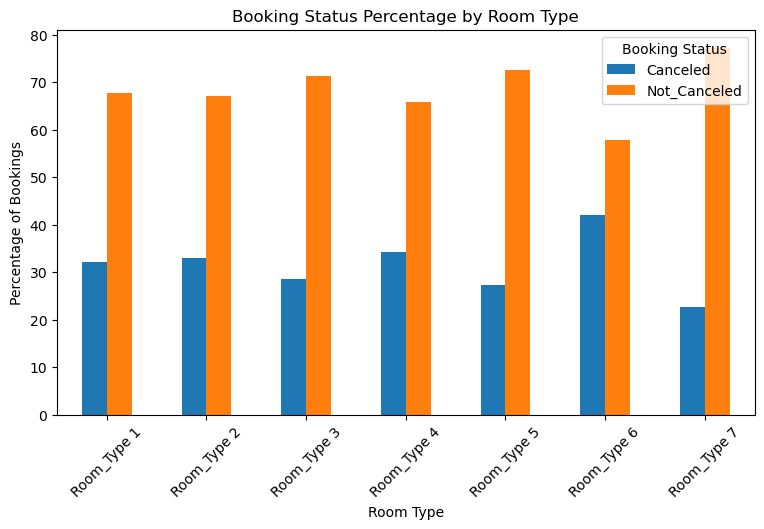

In [64]:
# Visualize cancellation rate by room type

room_cancellation.plot(kind='bar', figsize=(9, 5))

plt.title('Booking Status Percentage by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Percentage of Bookings')
plt.xticks(rotation=45)
plt.legend(title='Booking Status')
plt.show()

#### Booking Status by Room Type Observation

Cancellation rates differ across room types. *Room_Type 6* has the highest cancellation rate at about 42.1%, followed by *Room_Type 4* at about 34.2%.

*Room_Type 7* has the lowest cancellation rate at about 22.8%, followed by *Room_Type 5* at about 27.4% and *Room_Type 3* at about 28.6%.

The most common room type from the earlier univariate analysis was *Room_Type 1*, and its cancellation rate is about 32.3%, which is close to the overall cancellation rate. This suggests that some room types may be linked to different cancellation patterns, but the booking volume for each room type should also be considered before drawing strong conclusions.

In [65]:
# Calculate cancellation rate by market segment

market_cancellation = df.groupby('market segment type')['booking status'].value_counts(normalize=True).unstack() * 100

market_cancellation

booking status,Canceled,Not_Canceled
market segment type,,
Aviation,29.600000,70.400000
Complementary,NaN,100.000000
Corporate,10.939831,89.060169
Offline,29.968634,70.031366
Online,36.515667,63.484333


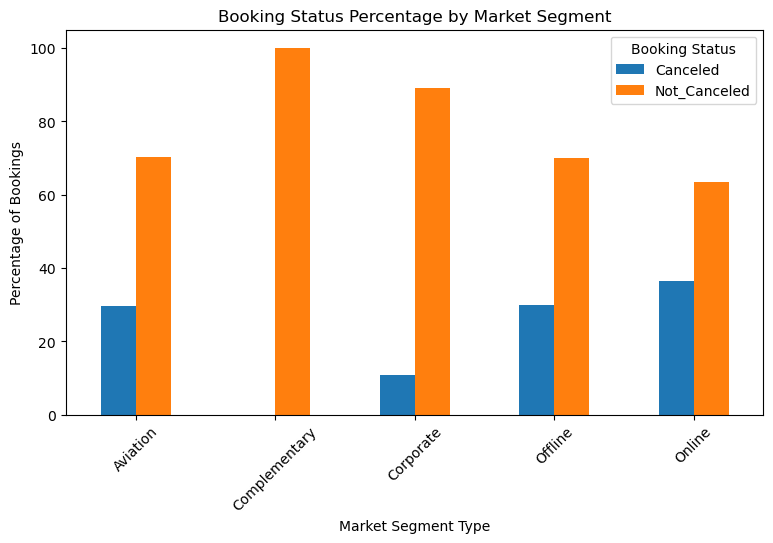

In [66]:
# Visualize cancellation rate by market segment

market_cancellation.plot(kind='bar', figsize=(9, 5))

plt.title('Booking Status Percentage by Market Segment')
plt.xlabel('Market Segment Type')
plt.ylabel('Percentage of Bookings')
plt.xticks(rotation=45)
plt.legend(title='Booking Status')
plt.show()

#### Booking Status by Market Segment Observation

Cancellation rates vary clearly across market segments. *Online* bookings have the highest cancellation rate at about 36.5%, followed by *Offline* and *Aviation* bookings, both around 29% to 30%.

*Corporate* bookings have a much lower cancellation rate at about 10.9%, suggesting that corporate customers may be more likely to keep their bookings.

The *Complementary* segment shows no cancellations in this dataset, but this segment had a much smaller booking volume in the earlier univariate analysis, so the result should be interpreted with caution.

In [67]:
# Compare average numerical values by booking status

numeric_by_status = df.groupby('booking status')[
    ['lead time', 'average price', 'total_nights', 'total_guests', 'special requests']
].mean()

numeric_by_status

,lead time,average price,total_nights,total_guests,special requests
booking status,,,,,
Canceled,139.270325,110.598218,3.279162,2.033749,0.334708
Not_Canceled,58.955307,99.942401,2.886112,1.909874,0.759173


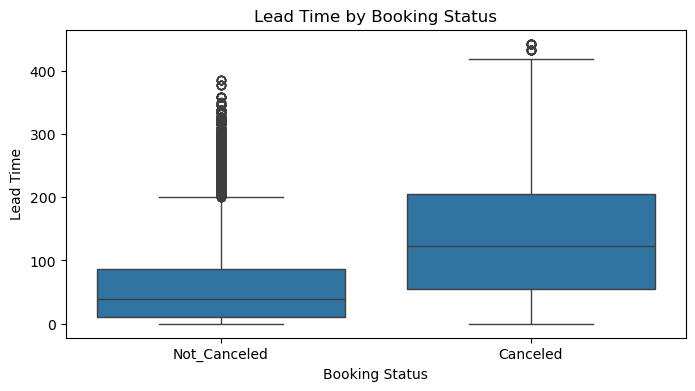

In [68]:
# Compare lead time by booking status

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='booking status', y='lead time')
plt.title('Lead Time by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Lead Time')
plt.show()

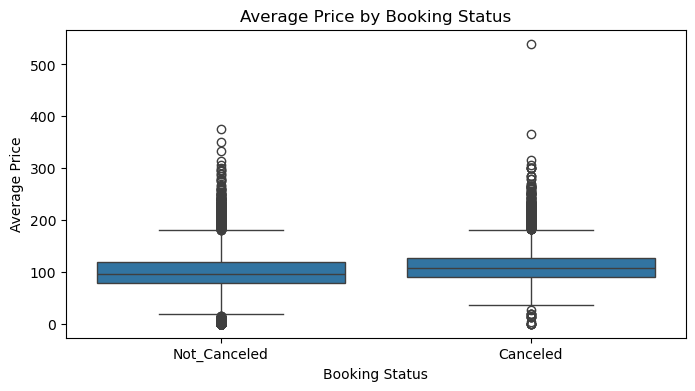

In [69]:
# Compare average price by booking status

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='booking status', y='average price')
plt.title('Average Price by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Average Price')
plt.show()

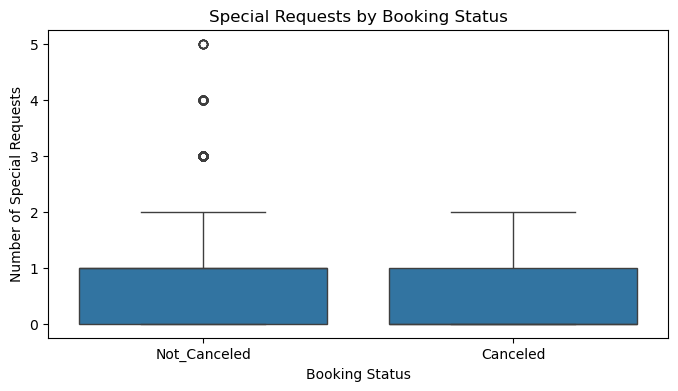

In [70]:
# Compare special requests by booking status

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='booking status', y='special requests')
plt.title('Special Requests by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Number of Special Requests')
plt.show()

#### Numerical Variables by Booking Status Observation

The summary table and boxplots show clear differences between canceled and not canceled bookings.

Canceled bookings have a much higher average *lead time*, which suggests that customers who book further in advance are more likely to cancel. Canceled bookings also have a slightly higher average *average price* than not canceled bookings.

Not canceled bookings have a higher average number of *special requests*. This may suggest that customers who make special requests are more engaged with their booking and may be less likely to cancel.

*Total_nights* and *total_guests* show smaller differences between the two booking groups compared with *lead time*, *average price*, and *special requests*.

### Time-Based Bivariate Analysis

This section explores how booking cancellations vary across time-based features created from the reservation date.

The goal is to see whether cancellation patterns differ by year, month, quarter, or day of the week.

In [71]:
# Calculate cancellation rate by reservation month

month_cancellation = df.groupby('reservation_month')['booking status'].value_counts(normalize=True).unstack() * 100

month_cancellation

booking status,Canceled,Not_Canceled
reservation_month,,
1,2.366864,97.633136
2,25.419664,74.580336
3,29.686175,70.313825
4,36.390208,63.609792
5,36.514044,63.485956
6,40.305963,59.694037
7,44.984594,55.015406
8,39.024390,60.975610
9,33.369471,66.630529


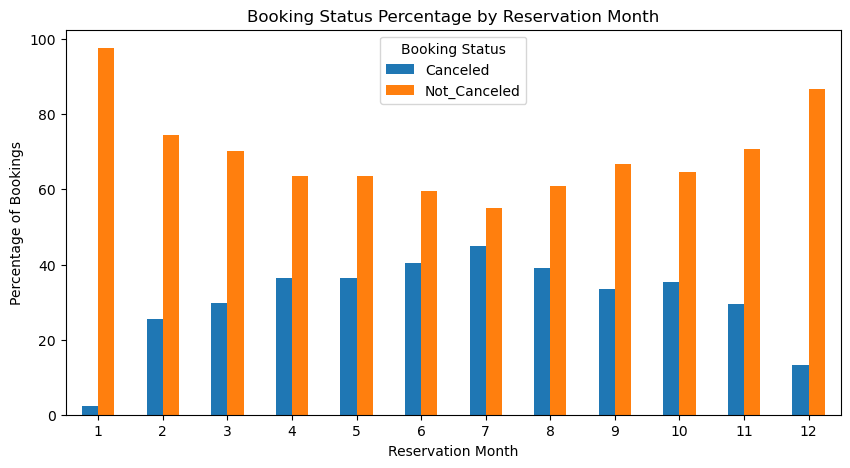

In [72]:
# Visualize cancellation rate by reservation month

month_cancellation.plot(kind='bar', figsize=(10, 5))

plt.title('Booking Status Percentage by Reservation Month')
plt.xlabel('Reservation Month')
plt.ylabel('Percentage of Bookings')
plt.xticks(rotation=0)
plt.legend(title='Booking Status')
plt.show()

In [73]:
# Calculate cancellation rate by reservation year

year_cancellation = df.groupby('reservation_year')['booking status'].value_counts(normalize=True).unstack() * 100

year_cancellation

booking status,Canceled,Not_Canceled
reservation_year,,
2015,NaN,100.000000
2016,100.000000,NaN
2017,14.763659,85.236341
2018,36.727212,63.272788


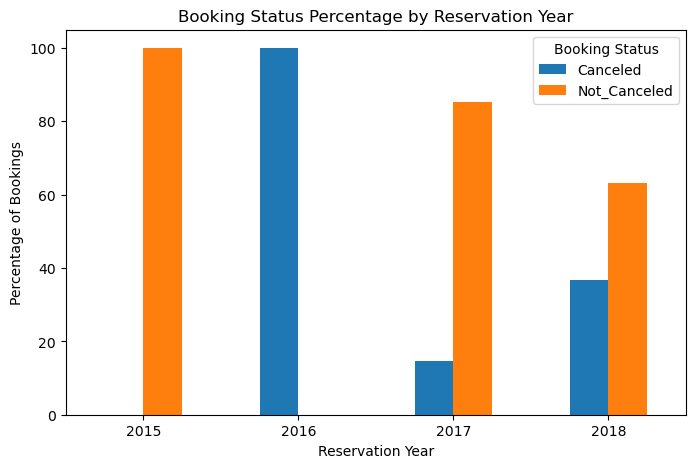

In [74]:
# Visualize cancellation rate by reservation year

year_cancellation.plot(kind='bar', figsize=(8, 5))

plt.title('Booking Status Percentage by Reservation Year')
plt.xlabel('Reservation Year')
plt.ylabel('Percentage of Bookings')
plt.xticks(rotation=0)
plt.legend(title='Booking Status')
plt.show()

In [75]:
# Calculate cancellation rate by reservation day of week

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_cancellation = df.groupby('reservation_day_of_week')['booking status'].value_counts(normalize=True).unstack() * 100
day_cancellation = day_cancellation.reindex(day_order)

day_cancellation

booking status,Canceled,Not_Canceled
reservation_day_of_week,,
Monday,30.762082,69.237918
Tuesday,32.381147,67.618853
Wednesday,32.812805,67.187195
Thursday,31.463146,68.536854
Friday,31.773139,68.226861
Saturday,31.937269,68.062731
Sunday,37.337027,62.662973


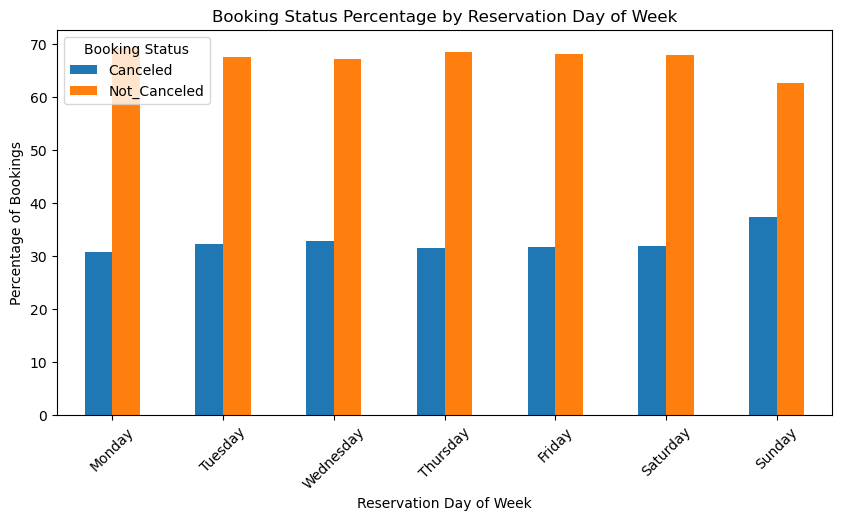

In [76]:
# Visualize cancellation rate by reservation day of week

day_cancellation.plot(kind='bar', figsize=(10, 5))

plt.title('Booking Status Percentage by Reservation Day of Week')
plt.xlabel('Reservation Day of Week')
plt.ylabel('Percentage of Bookings')
plt.xticks(rotation=45)
plt.legend(title='Booking Status')
plt.show()

#### Time-Based Bivariate Analysis Observations

Cancellation rates vary by reservation month. The highest cancellation rate appears in July, followed by June, August, April, May, and October. January and December have much lower cancellation rates compared with most other months.

The year-based chart shows that 2018 has a higher cancellation rate than 2017. However, 2015 and 2016 show unusual patterns, with 2015 showing only not canceled bookings and 2016 showing only canceled bookings. These years may have very small record counts, so they should be interpreted carefully.

Cancellation rates by day of the week are fairly similar across most days. Sunday has the highest cancellation rate, while Monday has the lowest, but the difference is not as strong as the patterns seen for lead time, market segment, or reservation month.

In [77]:
# Check booking count by reservation year

df['reservation_year'].value_counts().sort_index()

reservation_year
2015        1
2016        1
2017     6516
2018    29730
Name: count, dtype: int64

In [78]:
# Check booking count by reservation month

df['reservation_month'].value_counts().sort_index()

reservation_month
1     1014
2     1668
3     2358
4     2737
5     2599
6     3203
7     2921
8     3813
9     4612
10    5320
11    2981
12    3022
Name: count, dtype: int64

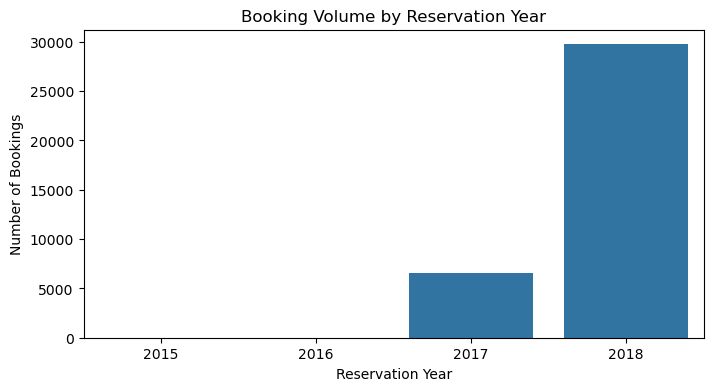

In [79]:
# Visualize booking volume by reservation year

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='reservation_year', order=sorted(df['reservation_year'].unique()))
plt.title('Booking Volume by Reservation Year')
plt.xlabel('Reservation Year')
plt.ylabel('Number of Bookings')
plt.show()

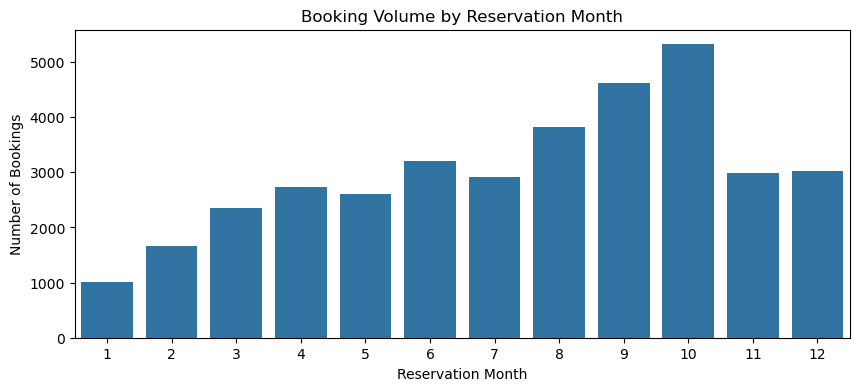

In [80]:
# Visualize booking volume by reservation month

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='reservation_month', order=sorted(df['reservation_month'].unique()))
plt.title('Booking Volume by Reservation Month')
plt.xlabel('Reservation Month')
plt.ylabel('Number of Bookings')
plt.show()

#### Booking Volume by Year and Month Observation

Most records in the dataset are from 2018, followed by 2017. The years 2015 and 2016 each contain only one booking, so their cancellation rates should not be interpreted as meaningful trends.

Monthly booking volume varies across the year. October has the highest number of bookings, followed by September and August. January has the lowest booking volume. This suggests that reservation activity is not evenly distributed across the year.

## Multivariate Analysis

Multivariate analysis looks at relationships between three or more variables. This section explores how cancellation patterns vary across multiple booking features at the same time.

In [81]:
# Create a cancellation indicator column

df['is_canceled'] = np.where(df['booking status'] == 'Canceled', 1, 0)

In [82]:
# Calculate cancellation rate by market segment and reservation month

market_month_cancellation = df.pivot_table(
    values='is_canceled',
    index='market segment type',
    columns='reservation_month',
    aggfunc='mean'
) * 100

market_month_cancellation

reservation_month,1,2,3,4,5,6,7,8,9,10,11,12
market segment type,,,,,,,,,,,,
Aviation,NaN,0.000000,0.000000,16.000000,65.517241,16.666667,0.000000,NaN,33.333333,10.344828,33.333333,NaN
Complementary,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Corporate,5.660377,6.500000,6.586826,9.230769,30.136986,14.141414,7.079646,21.487603,12.403101,6.787330,9.787234,0.000000
Offline,0.000000,23.130841,20.631970,40.090772,33.794163,41.210795,45.226917,23.378378,32.140615,32.044466,31.835206,0.139665
Online,3.191489,30.528376,35.525507,36.524823,38.401908,41.676436,47.324337,44.387052,36.752137,40.561570,31.392271,19.637610


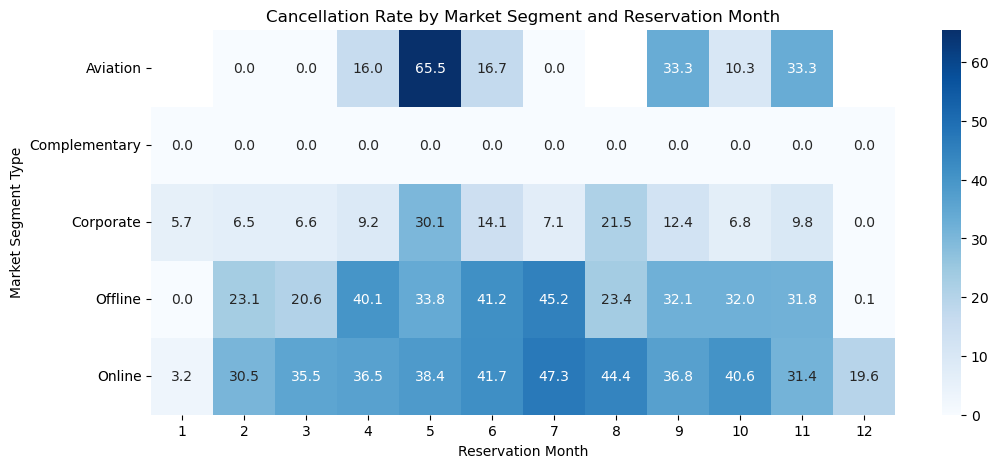

In [83]:
# Visualize cancellation rate by market segment and reservation month

plt.figure(figsize=(12, 5))
sns.heatmap(market_month_cancellation, annot=True, fmt='.1f', cmap='Blues')
plt.title('Cancellation Rate by Market Segment and Reservation Month')
plt.xlabel('Reservation Month')
plt.ylabel('Market Segment Type')
plt.show()

#### Cancellation Rate by Market Segment and Month Observation

The heatmap shows that cancellation patterns vary across both market segment and reservation month.

*Online* bookings show consistently higher cancellation rates across many months, especially from March to October. The highest online cancellation rate appears in July, followed by August, June, and October.

*Offline* bookings also show higher cancellation rates in some months, especially April, June, and July. However, the pattern is less consistent than the online segment.

*Corporate* bookings generally have lower cancellation rates across most months, although May shows a noticeable increase. This supports the earlier finding that corporate bookings are less likely to cancel compared with online and offline bookings.

The *Complementary* segment shows no cancellations across the months, but this should be interpreted carefully because the segment has a small booking volume. The *Aviation* segment also has some missing month values, likely because there were no aviation bookings in those months.

In [84]:
# Create lead time groups

def lead_time_group(days):
    if days <= 30:
        return '0-30 days'
    elif days <= 90:
        return '31-90 days'
    elif days <= 180:
        return '91-180 days'
    else:
        return '181+ days'

df['lead_time_group'] = df['lead time'].apply(lead_time_group)

In [85]:
# Check booking count by lead time group

df['lead_time_group'].value_counts()

lead_time_group
0-30 days      12394
31-90 days     10809
91-180 days     7765
181+ days       5280
Name: count, dtype: int64

In [86]:
# Calculate cancellation rate by lead time group and market segment

lead_market_cancellation = df.pivot_table(
    values='is_canceled',
    index='lead_time_group',
    columns='market segment type',
    aggfunc='mean'
) * 100

lead_market_cancellation

market segment type,Aviation,Complementary,Corporate,Offline,Online
lead_time_group,,,,,
0-30 days,29.6,0.0,6.973848,4.683607,18.285783
181+ days,NaN,0.0,73.684211,67.611191,81.052632
31-90 days,NaN,0.0,17.883212,7.662712,33.067028
91-180 days,NaN,0.0,40.178571,35.864979,49.791625


In [87]:
# Reorder lead time groups

lead_time_order = ['0-30 days', '31-90 days', '91-180 days', '181+ days']

lead_market_cancellation = lead_market_cancellation.reindex(lead_time_order)

lead_market_cancellation

market segment type,Aviation,Complementary,Corporate,Offline,Online
lead_time_group,,,,,
0-30 days,29.6,0.0,6.973848,4.683607,18.285783
31-90 days,NaN,0.0,17.883212,7.662712,33.067028
91-180 days,NaN,0.0,40.178571,35.864979,49.791625
181+ days,NaN,0.0,73.684211,67.611191,81.052632


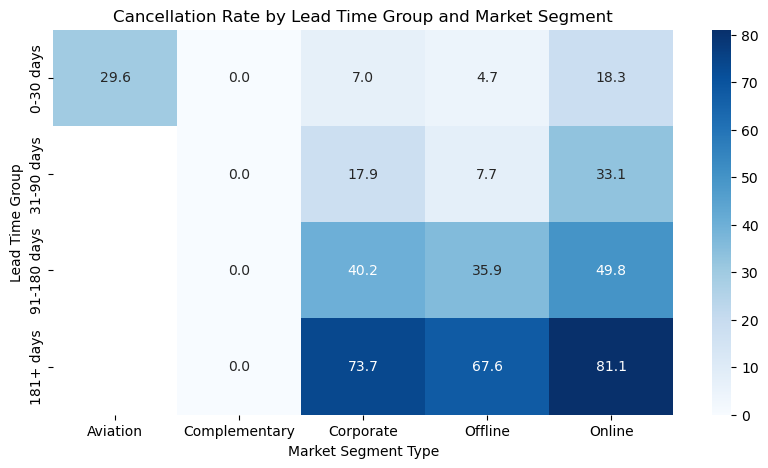

In [88]:
# Visualize cancellation rate by lead time group and market segment

plt.figure(figsize=(10, 5))
sns.heatmap(lead_market_cancellation, annot=True, fmt='.1f', cmap='Blues')
plt.title('Cancellation Rate by Lead Time Group and Market Segment')
plt.xlabel('Market Segment Type')
plt.ylabel('Lead Time Group')
plt.show()

#### Cancellation Rate by Lead Time Group and Market Segment Observation

The heatmap shows a clear relationship between lead time and cancellation rate. As lead time increases, cancellation rates also increase across most market segments.

For *Online* bookings, the cancellation rate rises from about 18.3% for bookings made within 0 to 30 days to about 81.1% for bookings made 181 or more days in advance.

A similar pattern appears for *Offline* bookings, where cancellation increases from about 4.7% in the shortest lead time group to about 67.6% in the longest lead time group.

*Corporate* bookings also show this pattern, increasing from about 7.0% to about 73.7% across the lead time groups. This suggests that even though corporate bookings had a lower cancellation rate overall, very long lead times still increase cancellation risk.

The *Complementary* segment shows 0% cancellation across all lead time groups, but this should be interpreted carefully because the segment has a smaller booking volume. The missing values for *Aviation* suggest that there were no aviation bookings in some lead time groups.

In [89]:
# Calculate cancellation rate by special requests and lead time group

request_lead_cancellation = df.pivot_table(
    values='is_canceled',
    index='special requests',
    columns='lead_time_group',
    aggfunc='mean'
) * 100

request_lead_cancellation

lead_time_group,0-30 days,181+ days,31-90 days,91-180 days
special requests,,,,
0,21.075167,76.243888,36.409426,57.524932
1,9.840810,72.888889,18.425414,28.584110
2,1.511487,70.557029,2.830189,32.180294
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,NaN,0.000000,0.000000


In [90]:
# Reorder lead time group columns

request_lead_cancellation = request_lead_cancellation[lead_time_order]

request_lead_cancellation

lead_time_group,0-30 days,31-90 days,91-180 days,181+ days
special requests,,,,
0,21.075167,36.409426,57.524932,76.243888
1,9.840810,18.425414,28.584110,72.888889
2,1.511487,2.830189,32.180294,70.557029
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,NaN


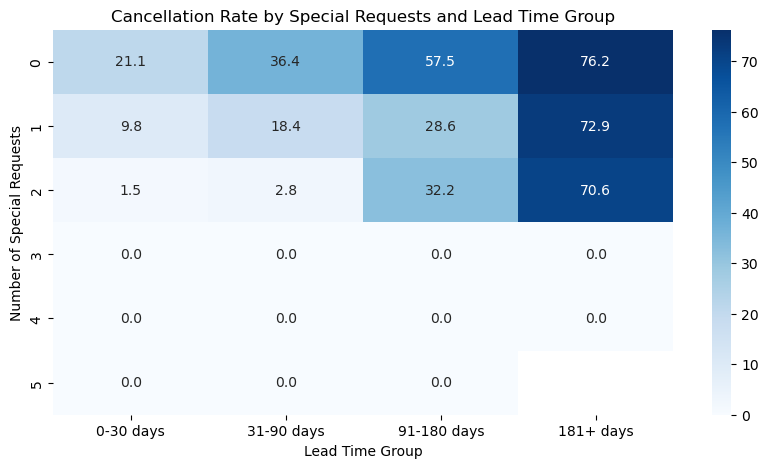

In [91]:
# Visualize cancellation rate by special requests and lead time group

plt.figure(figsize=(10, 5))
sns.heatmap(request_lead_cancellation, annot=True, fmt='.1f', cmap='Blues')
plt.title('Cancellation Rate by Special Requests and Lead Time Group')
plt.xlabel('Lead Time Group')
plt.ylabel('Number of Special Requests')
plt.show()

#### Cancellation Rate by Special Requests and Lead Time Group Observation

The heatmap shows that cancellation rates generally increase as lead time gets longer.

For bookings with no special requests, the cancellation rate rises from about 21.1% for bookings made within 0 to 30 days to about 76.2% for bookings made 181 or more days in advance.

Bookings with 1 or 2 special requests have lower cancellation rates than bookings with no special requests across most lead time groups. This suggests that customers who make special requests may be more engaged with their booking and less likely to cancel.

However, in the longest lead time group, cancellation rates remain high even when customers have 1 or 2 special requests. This suggests that long lead time is still a strong cancellation risk factor.

Rows with 3 or more special requests show very low or zero cancellation rates, but these groups likely have fewer bookings, so the results should be interpreted with caution.

### Correlation Analysis

Correlation analysis helps identify the strength and direction of relationships between numerical variables.

For this project, the main focus is the relationship between numerical features and the cancellation indicator, *is_canceled*.

In [92]:
# Select numerical columns for correlation analysis

correlation_columns = [
    'number of adults',
    'number of children',
    'number of weekend nights',
    'number of week nights',
    'car parking space',
    'lead time',
    'repeated',
    'P-C',
    'P-not-C',
    'average price',
    'special requests',
    'reservation_month',
    'reservation_quarter',
    'total_nights',
    'total_guests',
    'has_children',
    'is_canceled'
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests,reservation_month,reservation_quarter,total_nights,total_guests,has_children,is_canceled
number of adults,1.000000,-0.020352,0.103654,0.105252,0.011846,0.096826,-0.192036,-0.047501,-0.118808,0.296507,0.189017,0.020753,0.021064,0.133686,0.785253,0.003792,0.086525
number of children,-0.020352,1.000000,0.029547,0.024402,0.034420,-0.046876,-0.036270,-0.016383,-0.021135,0.337268,0.124459,-0.002856,0.001813,0.033684,0.603066,0.922357,0.032962
number of weekend nights,0.103654,0.029547,1.000000,0.179445,-0.031199,0.046655,-0.067351,-0.020689,-0.026386,-0.004416,0.060510,-0.009379,0.003809,0.629383,0.101000,0.033239,0.061630
number of week nights,0.105252,0.024402,0.179445,1.000000,-0.049052,0.149704,-0.100312,-0.030254,-0.049398,0.022769,0.045943,0.037701,0.029600,0.877421,0.099089,0.024529,0.092732
car parking space,0.011846,0.034420,-0.031199,-0.049052,1.000000,-0.066269,0.110459,0.027179,0.063047,0.061701,0.087933,-0.015034,-0.015045,-0.053960,0.030768,0.032520,-0.086047
lead time,0.096826,-0.046876,0.046655,0.149704,-0.066269,1.000000,-0.135900,-0.045781,-0.077929,-0.062696,-0.101798,0.136191,0.147882,0.141004,0.048222,-0.045840,0.438583
repeated,-0.192036,-0.036270,-0.067351,-0.100312,0.110459,-0.135900,1.000000,0.391248,0.538730,-0.174666,-0.011818,0.001279,-0.000613,-0.112081,-0.175679,-0.037255,-0.107479
P-C,-0.047501,-0.016383,-0.020689,-0.030254,0.027179,-0.045781,0.391248,1.000000,0.468671,-0.063317,-0.003290,-0.038659,-0.031926,-0.033987,-0.048045,-0.017679,-0.033868
P-not-C,-0.118808,-0.021135,-0.026386,-0.049398,0.063047,-0.077929,0.538730,0.468671,1.000000,-0.113528,0.027217,-0.010293,-0.012181,-0.051887,-0.107881,-0.022218,-0.060041
average price,0.296507,0.337268,-0.004416,0.022769,0.061701,-0.062696,-0.174666,-0.063317,-0.113528,1.000000,0.184249,0.053960,0.049051,0.015832,0.445442,0.303515,0.142584


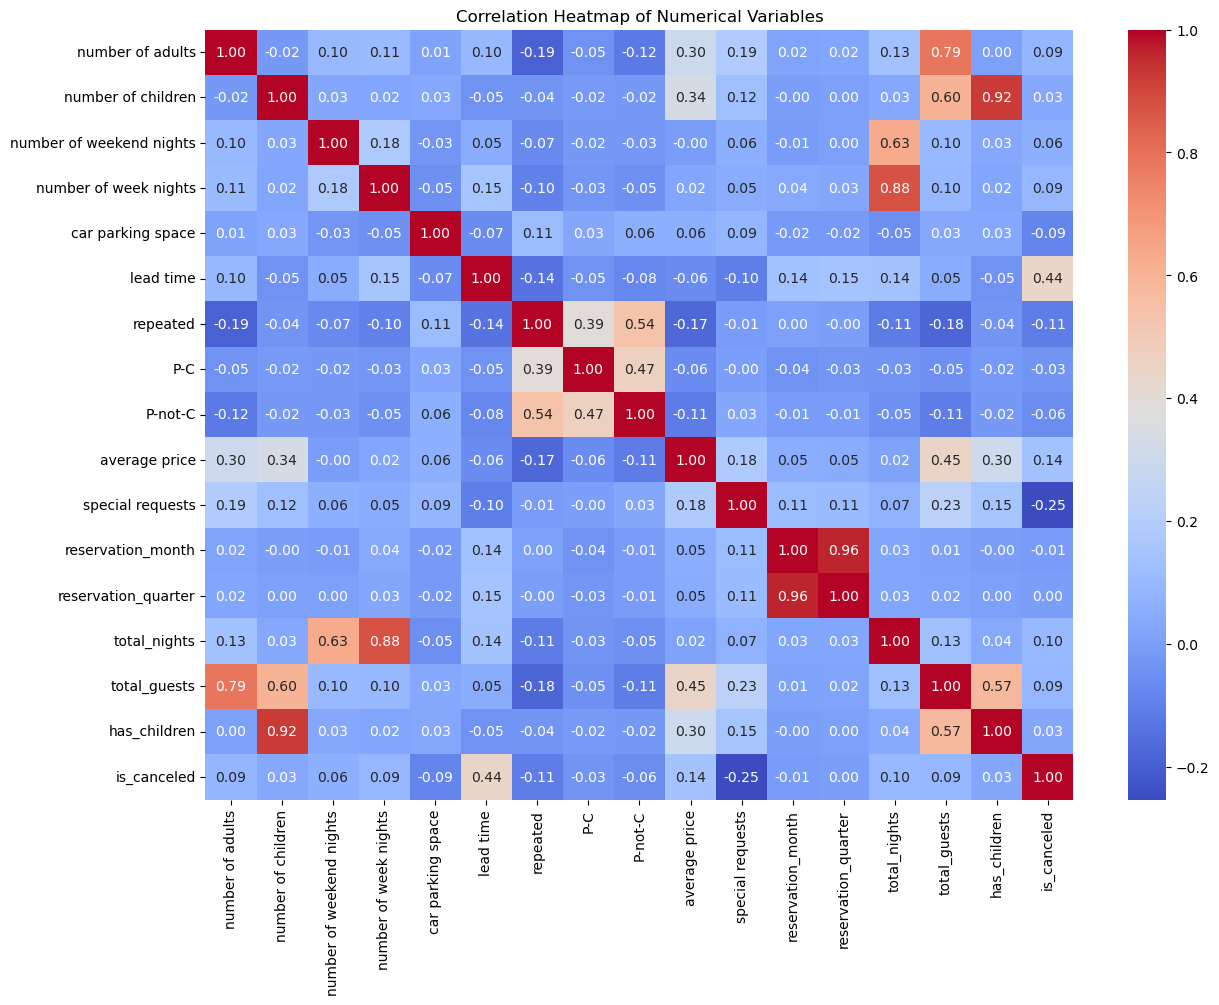

In [93]:
# Visualize the correlation matrix

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

#### Correlation Analysis Observation

The correlation heatmap shows that *lead time* has the strongest positive relationship with *is_canceled*, with a correlation of about 0.44. This supports the earlier finding that bookings made further in advance are more likely to be canceled.

*Special requests* has the strongest negative relationship with *is_canceled*, with a correlation of about -0.25. This suggests that bookings with more special requests are less likely to be canceled.

*Average price* has a weak positive relationship with cancellation, while *repeated* and *car parking space* have weak negative relationships with cancellation.

Some variables are strongly related to each other. For example, *reservation_month* and *reservation_quarter* are highly correlated because quarter is created from month. *Number of children* and *has_children* are also strongly related because *has_children* was created from the children column. These relationships should be considered before model training to avoid using too many overlapping features.

## Summary of Key EDA Findings

The exploratory data analysis identified several patterns related to booking cancellations.

1. *Lead time* appears to be one of the strongest cancellation-related variables. Bookings made further in advance had much higher cancellation rates than bookings made closer to the reservation date.

2. *Market segment type* is also important. Online bookings had the highest cancellation rate, while corporate bookings had a much lower cancellation rate.

3. *Special requests* appear to be linked with lower cancellation risk. Customers with more special requests were generally less likely to cancel their bookings.

4. *Average price* was slightly higher among canceled bookings, suggesting that price may have some relationship with cancellation behaviour.

5. Cancellation patterns also varied by month, with higher cancellation rates around the middle of the year. However, time-based patterns should be interpreted alongside booking volume.

6. Some variables, such as *reservation_month* and *reservation_quarter*, or *number of children* and *has_children*, are strongly related to each other because they capture similar information. This will be considered during model preparation.

Overall, the EDA suggests that *lead time*, *market segment type*, *special requests*, *average price*, and selected booking characteristics may be useful predictors for the machine learning model.

## Model Preparation

This section prepares the dataset for supervised machine learning.

The goal is to predict whether a booking will be canceled or not canceled. The target variable will be *is_canceled*, where 1 represents a canceled booking and 0 represents a not canceled booking.

In [94]:
# Create a copy of the dataset for modeling

model_df = df.copy()

In [95]:
# Drop columns that should not be used as model features

model_df = model_df.drop(columns=['Booking_ID', 'date of reservation', 'booking status'])

In [96]:
# Check the shape of the modeling dataset

model_df.shape

(36248, 24)

In [97]:
# Preview the modeling dataset

model_df.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,...,reservation_year,reservation_month,reservation_day,reservation_day_of_week,reservation_quarter,total_nights,total_guests,has_children,is_canceled,lead_time_group
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,...,2015,10,2,Friday,4,7,2,1,0,181+ days
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,...,2018,11,6,Tuesday,4,4,1,0,0,0-30 days
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,...,2018,2,28,Wednesday,1,4,3,1,1,0-30 days
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,...,2017,5,20,Saturday,2,2,1,0,1,181+ days
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,...,2018,4,11,Wednesday,2,3,1,0,1,31-90 days


#### Modeling Dataset Preparation Observation

A separate copy of the cleaned dataset was created for machine learning. The identifier column, raw date column, and original target label were removed from the modeling dataset.

The modeling dataset now contains 36,248 rows and 24 columns. The target variable for model training is *is_canceled*, where 1 represents a canceled booking and 0 represents a not canceled booking.

### Separate Features and Target Variable

The dataset is separated into input features and the target variable.

The input features are stored in *X*, while the target variable, *is_canceled*, is stored in *y*.

In [98]:
# Separate features and target variable

X = model_df.drop(columns=['is_canceled'])
y = model_df['is_canceled']

In [99]:
# Check the shape of the feature set and target variable

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (36248, 23)
y shape: (36248,)


In [100]:
# Preview the feature set

X.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,...,special requests,reservation_year,reservation_month,reservation_day,reservation_day_of_week,reservation_quarter,total_nights,total_guests,has_children,lead_time_group
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,...,0,2015,10,2,Friday,4,7,2,1,181+ days
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,...,1,2018,11,6,Tuesday,4,4,1,0,0-30 days
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,...,0,2018,2,28,Wednesday,1,4,3,1,0-30 days
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,...,1,2017,5,20,Saturday,2,2,1,0,181+ days
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,...,0,2018,4,11,Wednesday,2,3,1,0,31-90 days


In [101]:
# Check target variable distribution

y.value_counts(normalize=True) * 100

is_canceled
0    67.22026
1    32.77974
Name: proportion, dtype: float64

#### Feature and Target Split Observation

The modeling dataset was separated into input features and the target variable. The feature set, *X*, contains 23 predictor variables, while *y* contains the target variable, *is_canceled*.

The target variable remains somewhat imbalanced, with about 67.2% not canceled bookings and 32.8% canceled bookings. This will be considered during model evaluation.

In [102]:
# Identify categorical and numerical columns in the feature set

categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(include='number').columns

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
Index(['type of meal', 'room type', 'market segment type',
       'reservation_day_of_week', 'lead_time_group'],
      dtype='object')

Numerical Features:
Index(['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'car parking space', 'lead time', 'repeated',
       'P-C', 'P-not-C', 'average price', 'special requests',
       'reservation_year', 'reservation_month', 'reservation_day',
       'reservation_quarter', 'total_nights', 'total_guests', 'has_children'],
      dtype='object')


In [103]:
# Check the number of categorical and numerical features

print("Number of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))
print("Total features:", len(categorical_features) + len(numerical_features))

Number of categorical features: 5
Number of numerical features: 18
Total features: 23


#### Feature Type Check Observation

The feature set contains 5 categorical features and 18 numerical features, making 23 predictor variables in total.

The categorical variables will need to be encoded before model training because machine learning models require numerical input. The numerical features were selected using *include='number'* to capture all numeric data types, including integer and float columns.

In [104]:
# Encode categorical variables using one-hot encoding

X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

In [105]:
# Check the shape after encoding

X_encoded.shape

(36248, 40)

In [106]:
# Preview the encoded feature set

X_encoded.head()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,...,market segment type_Online,reservation_day_of_week_Monday,reservation_day_of_week_Saturday,reservation_day_of_week_Sunday,reservation_day_of_week_Thursday,reservation_day_of_week_Tuesday,reservation_day_of_week_Wednesday,lead_time_group_181+ days,lead_time_group_31-90 days,lead_time_group_91-180 days
0,1,1,2,5,0,224,0,0,0,88.00,...,False,False,False,False,False,False,False,True,False,False
1,1,0,1,3,0,5,0,0,0,106.68,...,True,False,False,False,False,True,False,False,False,False
2,2,1,1,3,0,1,0,0,0,50.00,...,True,False,False,False,False,False,True,False,False,False
3,1,0,0,2,0,211,0,0,0,100.00,...,True,False,True,False,False,False,False,True,False,False
4,1,0,1,2,0,48,0,0,0,77.00,...,True,False,False,False,False,False,True,False,True,False


In [107]:
# Confirm that all features are now numeric

X_encoded.dtypes.value_counts()

bool       22
int64      13
int32       4
float64     1
Name: count, dtype: int64

#### Categorical Encoding Observation

The categorical features were converted into numerical dummy variables using one-hot encoding. This expanded the feature set from 23 columns to 40 columns.

The new encoded columns are stored as Boolean values, where *True* means the booking belongs to that category and *False* means it does not. These Boolean values will be converted to integers so all model features are represented numerically.

In [108]:
# Convert only Boolean columns to integers

bool_columns = X_encoded.select_dtypes(include='bool').columns
X_encoded[bool_columns] = X_encoded[bool_columns].astype(int)

In [109]:
# Confirm data types after converting only Boolean columns

X_encoded.dtypes.value_counts()

int64      35
int32       4
float64     1
Name: count, dtype: int64

In [110]:
# Preview encoded feature set after conversion

X_encoded.head()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,...,market segment type_Online,reservation_day_of_week_Monday,reservation_day_of_week_Saturday,reservation_day_of_week_Sunday,reservation_day_of_week_Thursday,reservation_day_of_week_Tuesday,reservation_day_of_week_Wednesday,lead_time_group_181+ days,lead_time_group_31-90 days,lead_time_group_91-180 days
0,1,1,2,5,0,224,0,0,0,88.00,...,0,0,0,0,0,0,0,1,0,0
1,1,0,1,3,0,5,0,0,0,106.68,...,1,0,0,0,0,1,0,0,0,0
2,2,1,1,3,0,1,0,0,0,50.00,...,1,0,0,0,0,0,1,0,0,0
3,1,0,0,2,0,211,0,0,0,100.00,...,1,0,1,0,0,0,0,1,0,0
4,1,0,1,2,0,48,0,0,0,77.00,...,1,0,0,0,0,0,1,0,1,0


### Train-Test Split

The encoded dataset is split into training and testing sets. The training set will be used to train the machine learning models, while the testing set will be used to evaluate model performance.

Stratification is used to preserve the same cancellation and non-cancellation balance in both the training and testing sets.

In [111]:
# Import train-test split

from sklearn.model_selection import train_test_split

In [112]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [113]:
# Check the shape of the training and testing sets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (28998, 40)
X_test shape: (7250, 40)
y_train shape: (28998,)
y_test shape: (7250,)


In [114]:
# Check target distribution in training and testing sets

print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
is_canceled
0    67.221877
1    32.778123
Name: proportion, dtype: float64

Testing target distribution:
is_canceled
0    67.213793
1    32.786207
Name: proportion, dtype: float64


#### Train-Test Split Observation

The encoded dataset was split into training and testing sets using an 80/20 split. The training set contains 28,998 records, while the testing set contains 7,250 records.

Stratification preserved the target distribution in both sets. This means the proportion of canceled and not canceled bookings is nearly the same in the training and testing data, which supports fairer model evaluation.

## Model Development

### Baseline Model: Logistic Regression

Logistic Regression will be used as the baseline classification model. A baseline model provides an initial performance benchmark that can be compared with more advanced models later.

In [115]:
# Import Logistic Regression and evaluation metrics

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [116]:
# Create and train the Logistic Regression model

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

C:\Users\Owner\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [117]:
# Make predictions on the test set

y_pred_log = log_model.predict(X_test)

In [118]:
# Evaluate the Logistic Regression model

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.7980689655172414

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      4873
           1       0.73      0.61      0.67      2377

    accuracy                           0.80      7250
   macro avg       0.78      0.75      0.76      7250
weighted avg       0.79      0.80      0.79      7250



In [119]:
# Create confusion matrix for Logistic Regression

conf_matrix_log = confusion_matrix(y_test, y_pred_log)

conf_matrix_log

array([[4330,  543],
       [ 921, 1456]])

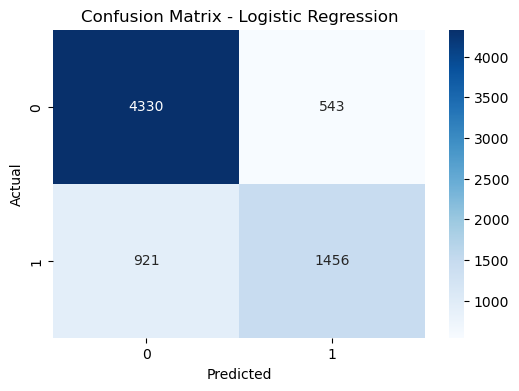

In [120]:
# Visualize confusion matrix for Logistic Regression

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_log, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Baseline Logistic Regression Model Observation

The baseline Logistic Regression model achieved an accuracy of about 79.8%. This means the model correctly predicted booking status for about 80% of the test records.

The model performed better at identifying not canceled bookings than canceled bookings. For not canceled bookings, recall was 0.89, meaning the model correctly identified most bookings that were actually not canceled.

For canceled bookings, recall was 0.61. This means the model correctly identified about 61% of actual cancellations, but missed some canceled bookings.

The confusion matrix shows that the model correctly predicted 4,330 not canceled bookings and 1,456 canceled bookings. However, it misclassified 921 canceled bookings as not canceled. Since the business goal is to predict cancellations early, reducing missed cancellations should be a focus when comparing models.

### Decision Tree Model

A Decision Tree model will be trained to compare against the baseline Logistic Regression model. Decision Trees can capture non-linear patterns in the data and may identify cancellation patterns that a simple linear model may miss.

In [121]:
# Import Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

In [122]:
# Create and train the Decision Tree model

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [123]:
# Make predictions on the test set

y_pred_tree = tree_model.predict(X_test)

In [124]:
# Evaluate the Decision Tree model

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.8612413793103448

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4873
           1       0.78      0.81      0.79      2377

    accuracy                           0.86      7250
   macro avg       0.84      0.85      0.84      7250
weighted avg       0.86      0.86      0.86      7250



In [125]:
# Create confusion matrix for Decision Tree

conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)

conf_matrix_tree

array([[4314,  559],
       [ 447, 1930]])

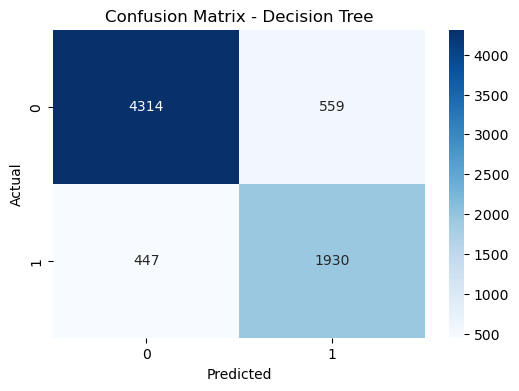

In [126]:
# Visualize confusion matrix for Decision Tree

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_tree, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Decision Tree Model Observation

The Decision Tree model achieved an accuracy of about 86.1%, which is higher than the baseline Logistic Regression model.

The model also performed better at identifying canceled bookings. Recall for the canceled class was 0.81, meaning the model correctly identified about 81% of actual cancellations.

The confusion matrix shows that the model correctly predicted 4,314 not canceled bookings and 1,930 canceled bookings. It missed 447 actual cancellations by predicting them as not canceled.

Compared with Logistic Regression, the Decision Tree reduced the number of missed cancellations, which is important for this project because the hotel wants to identify bookings that are likely to be canceled.

### Random Forest Model

A Random Forest model will be trained to compare against Logistic Regression and Decision Tree. Random Forest combines multiple decision trees and often provides stronger and more stable performance than a single tree.

In [127]:
# Import Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

In [128]:
# Create and train the Random Forest model

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [129]:
# Make predictions on the test set

y_pred_rf = rf_model.predict(X_test)

In [130]:
# Evaluate the Random Forest model

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9024827586206896

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      4873
           1       0.87      0.82      0.85      2377

    accuracy                           0.90      7250
   macro avg       0.89      0.88      0.89      7250
weighted avg       0.90      0.90      0.90      7250



In [131]:
# Create confusion matrix for Random Forest

conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

conf_matrix_rf

array([[4590,  283],
       [ 424, 1953]])

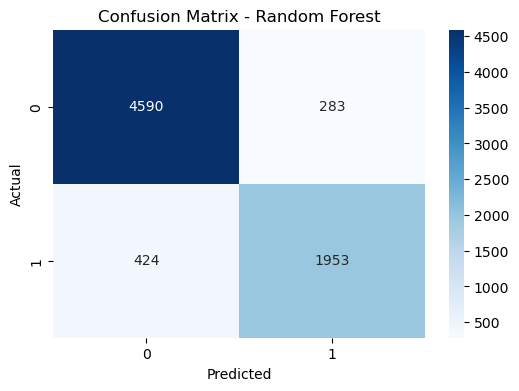

In [132]:
# Visualize confusion matrix for Random Forest

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Random Forest Model Observation

The Random Forest model achieved an accuracy of about 90.2%, making it the best-performing model so far.

The model performed well for both booking classes. For canceled bookings, recall was 0.82, meaning the model correctly identified about 82% of actual cancellations. Precision for canceled bookings was 0.87, meaning that when the model predicted a booking would be canceled, it was correct most of the time.

The confusion matrix shows that the model correctly predicted 4,590 not canceled bookings and 1,953 canceled bookings. It missed 424 actual cancellations by predicting them as not canceled.

Compared with Logistic Regression and Decision Tree, the Random Forest model provides stronger overall performance and better balance between precision and recall.

### ROC-AUC Evaluation for Random Forest

ROC-AUC is used as an additional evaluation metric to assess how well the Random Forest model separates canceled bookings from not canceled bookings across different classification thresholds.

In [133]:
# Import ROC-AUC score

from sklearn.metrics import roc_auc_score

In [134]:
# Calculate ROC-AUC for the Random Forest model

y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("ROC-AUC Score:", round(roc_auc_rf, 4))

ROC-AUC Score: 0.9535


The Random Forest model achieved a ROC-AUC score of about 0.954. This indicates that the model is very strong at separating canceled bookings from not canceled bookings across different classification thresholds.

This supports the model evaluation results and provides additional evidence that Random Forest is a strong final model for predicting booking cancellations.

### Gradient Boosting Model

A Gradient Boosting model will be trained to compare with the previous models. Gradient Boosting builds trees sequentially, where each new tree tries to correct the errors made by the previous ones.

In [135]:
# Import Gradient Boosting Classifier

from sklearn.ensemble import GradientBoostingClassifier

In [136]:
# Create and train the Gradient Boosting model

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [137]:
# Make predictions on the test set

y_pred_gb = gb_model.predict(X_test)

In [138]:
# Evaluate the Gradient Boosting model

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.848551724137931

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      4873
           1       0.81      0.70      0.75      2377

    accuracy                           0.85      7250
   macro avg       0.84      0.81      0.82      7250
weighted avg       0.85      0.85      0.85      7250



In [139]:
# Create confusion matrix for Gradient Boosting

conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

conf_matrix_gb

array([[4477,  396],
       [ 702, 1675]])

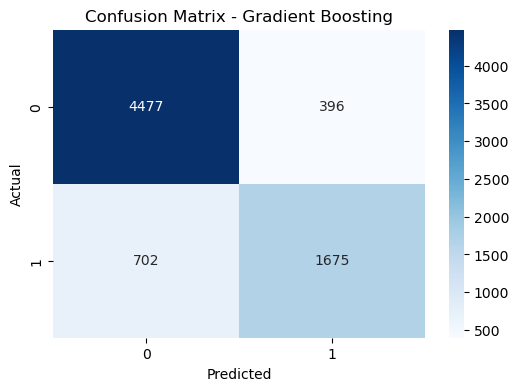

In [140]:
# Visualize confusion matrix for Gradient Boosting

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Gradient Boosting Model Observation

The Gradient Boosting model achieved an accuracy of about 84.9%. This is better than the baseline Logistic Regression model, but lower than the Decision Tree and Random Forest models.

For canceled bookings, the model had a recall of 0.70, meaning it correctly identified about 70% of actual cancellations. However, this is lower than the Random Forest model, which identified a larger share of canceled bookings.

The confusion matrix shows that the Gradient Boosting model correctly predicted 4,477 not canceled bookings and 1,675 canceled bookings. It missed 702 actual cancellations by predicting them as not canceled.

Based on these results, Gradient Boosting performed well, but Random Forest remains the strongest model so far.

In [141]:
# Import additional evaluation metrics

from sklearn.metrics import precision_score, recall_score, f1_score

In [142]:
# Create a model comparison table

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.798069,0.728364,0.612537,0.665448
1,Decision Tree,0.861241,0.775412,0.811948,0.793259
2,Random Forest,0.902483,0.873435,0.821624,0.846737
3,Gradient Boosting,0.848552,0.808788,0.704670,0.753147


In [143]:
# Sort models by F1 score

model_comparison.sort_values(by='F1 Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.902483,0.873435,0.821624,0.846737
1,Decision Tree,0.861241,0.775412,0.811948,0.793259
3,Gradient Boosting,0.848552,0.808788,0.704670,0.753147
0,Logistic Regression,0.798069,0.728364,0.612537,0.665448


#### Model Comparison Observation

Because the business goal is to identify bookings that may be canceled, evaluation should not rely on accuracy alone. Recall and F1-score for the canceled class are especially important because they show how well the model identifies actual cancellations while still balancing false alarms.

The model comparison table shows that Random Forest performed best among the four models tested. Random Forest achieved the highest accuracy at about 90.2% and the highest F1-score at about 84.7%. It also had the strongest precision and recall balance for predicting canceled bookings. 

Decision Tree had the second-best performance, with strong recall for canceled bookings, but Random Forest performed better overall.

Based on these results, Random Forest will be selected as the best model so far and will be used for further evaluation and tuning.

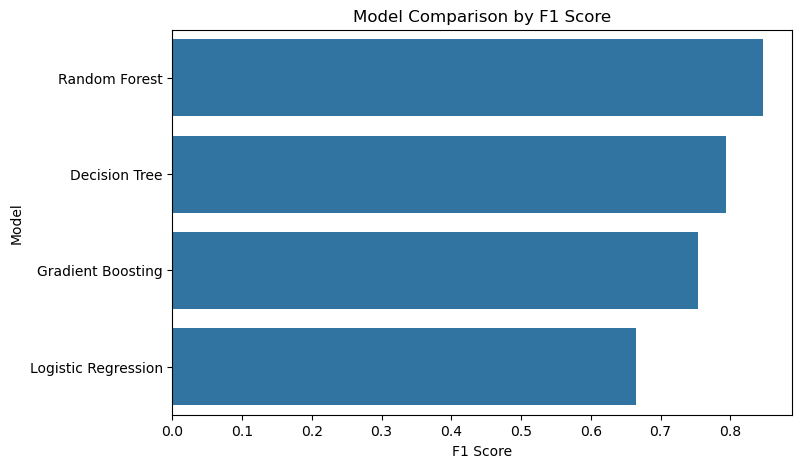

In [144]:
# Visualize model comparison by F1 score

plt.figure(figsize=(8, 5))
sns.barplot(data=model_comparison.sort_values(by='F1 Score', ascending=False),
            x='F1 Score',
            y='Model')

plt.title('Model Comparison by F1 Score')
plt.xlabel('F1 Score')
plt.ylabel('Model')
plt.show()

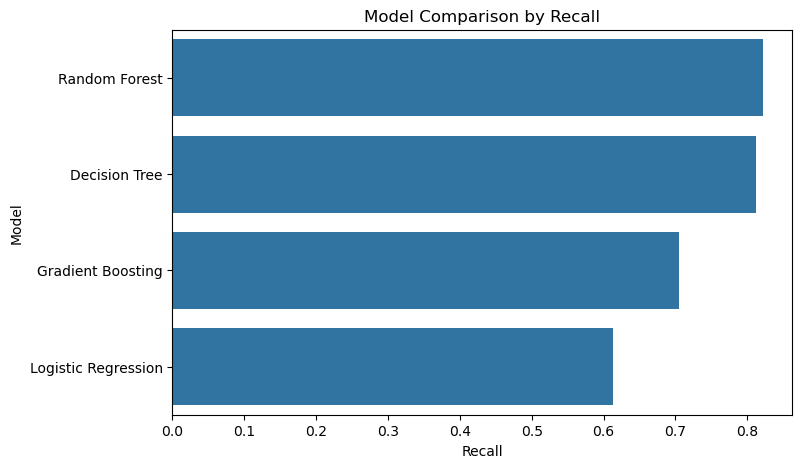

In [145]:
# Visualize model comparison by recall

plt.figure(figsize=(8, 5))
sns.barplot(data=model_comparison.sort_values(by='Recall', ascending=False),
            x='Recall',
            y='Model')

plt.title('Model Comparison by Recall')
plt.xlabel('Recall')
plt.ylabel('Model')
plt.show()

#### Model Comparison Visualization Observation

The model comparison charts show that Random Forest had the strongest overall performance. It achieved the highest F1-score and the highest recall among the four models.

This is important because the project is focused on predicting booking cancellations. A higher recall means the model is better at identifying bookings that are actually canceled.

Decision Tree also performed well, especially for recall, but Random Forest had a better balance between precision, recall, and F1-score. Based on these results, Random Forest remains the best model for this project.

### Feature Importance

Feature importance is used to identify which variables contributed most to the Random Forest model's predictions.

This helps explain the main factors linked to booking cancellations.

In [146]:
# Create feature importance dataframe for Random Forest

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
5,lead time,0.223231
9,average price,0.132231
10,special requests,0.102354
13,reservation_day,0.068782
12,reservation_month,0.058577
37,lead_time_group_181+ days,0.056997
15,total_nights,0.039793
3,number of week nights,0.033875
30,market segment type_Online,0.029394
2,number of weekend nights,0.024861


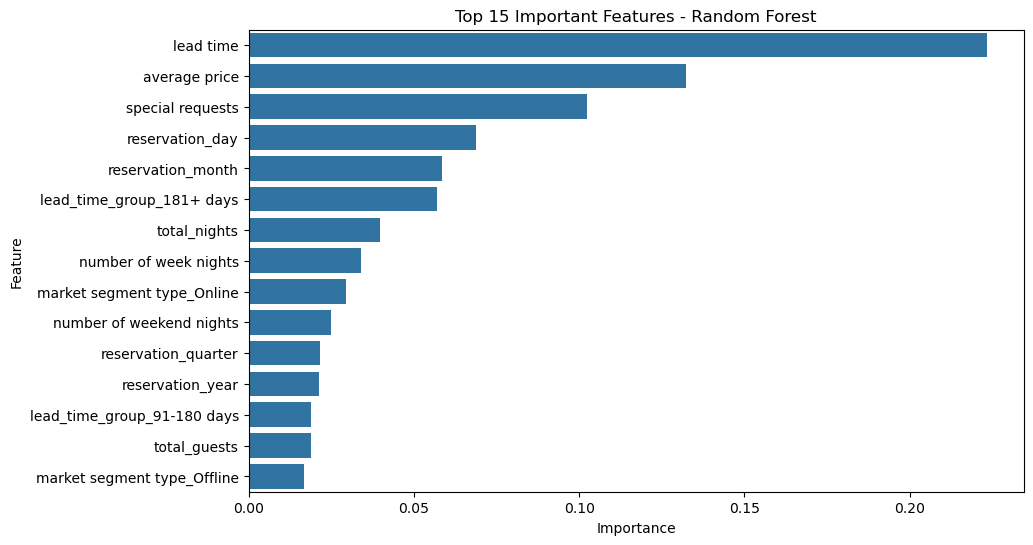

In [147]:
# Visualize top 15 feature importances

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='Importance', y='Feature')
plt.title('Top 15 Important Features - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

#### Random Forest Feature Importance Observation

The Random Forest feature importance results show that *lead time* is the most important predictor of booking cancellation. This supports the EDA finding that customers who book further in advance are more likely to cancel.

*Average price* and *special requests* are also among the top predictors. This suggests that pricing and customer engagement with the booking may play an important role in cancellation behaviour.

Date-related variables, such as *reservation_day* and *reservation_month*, also appear among the top features, showing that timing may contribute to cancellation patterns.

The feature *lead_time_group_181+ days* is also important, which reinforces the finding that very long lead times are linked with higher cancellation risk.

Market segment also appears in the top features, especially *market segment type_Online*, supporting the earlier analysis that online bookings had higher cancellation rates.

### Hyperparameter Tuning: Random Forest

Hyperparameter tuning is used to improve the Random Forest model by testing different combinations of model settings.

GridSearchCV will be used to search for the best combination of parameters. The model will be tuned using F1-score because the project needs a balance between precision and recall for predicting cancellations.

In [148]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

In [149]:
# Define parameter grid for Random Forest tuning

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': [None, 'balanced']
}

In [150]:
# Set up GridSearchCV for Random Forest

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

In [151]:
# Fit GridSearchCV on the training data

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [152]:
# Display the best parameters

grid_search.best_params_

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

In [153]:
# Display the best cross-validation F1 score

grid_search.best_score_

np.float64(0.837118604509091)

#### Random Forest Hyperparameter Tuning Observation

GridSearchCV identified the best Random Forest settings as using balanced class weights, 100 trees, no maximum depth limit, a minimum of 1 sample per leaf, and a minimum of 5 samples required to split a node.

The best cross-validation F1-score was about 0.837. This suggests that the tuned Random Forest model performs well during cross-validation and remains a strong model for predicting booking cancellations.

In [154]:
# Get the best tuned Random Forest model

best_rf_model = grid_search.best_estimator_

In [155]:
# Make predictions using the tuned Random Forest model

y_pred_best_rf = best_rf_model.predict(X_test)

In [156]:
# Evaluate the tuned Random Forest model

print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

Accuracy: 0.8975172413793103

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      4873
           1       0.85      0.83      0.84      2377

    accuracy                           0.90      7250
   macro avg       0.89      0.88      0.88      7250
weighted avg       0.90      0.90      0.90      7250



In [157]:
# Create confusion matrix for tuned Random Forest

conf_matrix_best_rf = confusion_matrix(y_test, y_pred_best_rf)

conf_matrix_best_rf

array([[4527,  346],
       [ 397, 1980]])

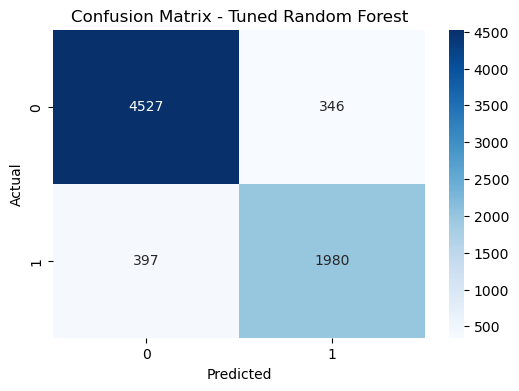

In [158]:
# Visualize confusion matrix for tuned Random Forest

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_best_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Tuned Random Forest Model Observation

The tuned Random Forest model achieved an accuracy of about 89.8%. This is slightly lower than the original Random Forest model, but the tuned model slightly improved recall for canceled bookings from 0.82 to 0.83.

The confusion matrix shows that the tuned model correctly predicted 4,527 not canceled bookings and 1,980 canceled bookings. It missed 397 actual cancellations by predicting them as not canceled.

Although tuning improved the model’s ability to catch canceled bookings, the original Random Forest had a slightly higher overall F1-score. Since the difference is small, both models perform strongly, but the final model choice should consider whether the business prefers slightly higher recall or slightly stronger overall balance.

In [159]:
# Compare original and tuned Random Forest models

rf_comparison = pd.DataFrame({
    'Model': ['Original Random Forest', 'Tuned Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best_rf)
    ]
})

rf_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Original Random Forest,0.902483,0.873435,0.821624,0.846737
1,Tuned Random Forest,0.897517,0.851247,0.832983,0.842016


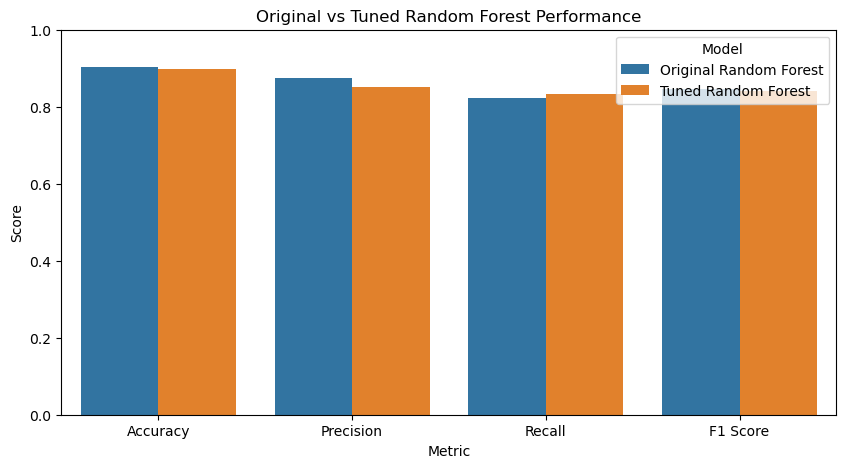

In [160]:
# Visualize comparison between original and tuned Random Forest

rf_comparison_melted = rf_comparison.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 5))
sns.barplot(data=rf_comparison_melted, x='Metric', y='Score', hue='Model')
plt.title('Original vs Tuned Random Forest Performance')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.show()

#### Original vs Tuned Random Forest Observation

The original Random Forest model performed slightly better overall than the tuned Random Forest model. It had higher accuracy, precision, and F1-score.

The tuned Random Forest model had slightly higher recall, meaning it identified a few more actual cancellations. However, this came with a small drop in precision and F1-score.

Since the original Random Forest provides the best overall balance between accuracy, precision, recall, and F1-score, it will be selected as the final model for this project.

## Final Model Selection

Based on the model comparison results, the Random Forest model was selected as the final model.

The Random Forest model achieved the strongest overall performance, with an accuracy of about 90.2% and an F1-score of about 84.7% for canceled bookings. It also performed well in identifying actual cancellations, with a recall of about 82.2%.

This model provides a strong balance between correctly identifying canceled bookings and avoiding too many false cancellation predictions.

### Model Limitations and Next Steps

Although the Random Forest model performed well, there are some limitations to consider.

First, the model was trained on historical booking data, so its performance may change if customer behaviour, pricing strategy, or booking policies change over time.

Second, some features are closely related to each other, such as *lead time* and *lead_time_group*, or *reservation_month* and *reservation_quarter*. These features may overlap in the information they provide.

Third, the model predicts cancellation risk, but it does not explain the personal reasons why customers cancel. Additional customer feedback or cancellation reason data could improve future analysis.

As a next step, Hotel Haven could test the model on newer booking data, monitor performance over time, and use the predictions as part of a proactive customer follow-up strategy.

## Business Recommendations

Based on the exploratory analysis and machine learning results, the following recommendations can help Hotel Haven reduce cancellation risk and improve booking management.

1. **Monitor long lead-time bookings more closely.**  
   Lead time was the strongest predictor of cancellation. Bookings made far in advance should be flagged for follow-up, especially those made more than 180 days before the reservation date.

2. **Prioritize retention strategies for online bookings.**  
   Online bookings had higher cancellation rates than other market segments. Hotel Haven could use reminder emails, flexible confirmation messages, or targeted incentives to encourage these customers to keep their bookings.

3. **Use special requests as a sign of stronger booking commitment.**  
   Customers with more special requests were less likely to cancel. This may suggest that more engaged customers are more committed to their stay.

4. **Review pricing patterns linked to cancellations.**  
   Average price was one of the top model features. Hotel Haven should review whether higher-priced bookings are more sensitive to cancellation and whether pricing, promotions, or booking conditions affect customer decisions.

5. **Use the model as an early warning tool.**  
   The Random Forest model can help identify bookings that are more likely to be canceled. This can support proactive follow-up, better room inventory planning, and improved staffing or resource allocation.

## Conclusion

This project analyzed hotel booking data to understand cancellation patterns and build a predictive model for booking status.

The analysis showed that cancellations were strongly linked to lead time, market segment type, special requests, average price, and reservation timing. Bookings made further in advance, especially online bookings, were more likely to be canceled, while bookings with more special requests were less likely to be canceled.

Several supervised machine learning models were trained and compared, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Random Forest performed best overall, achieving about 90.2% accuracy and the strongest F1-score among the models tested.

The final model can support Hotel Haven by helping identify bookings with higher cancellation risk, allowing the business to take earlier action and improve planning, customer retention, and resource management.